# Deep Reinforcement Learning Laboratory

In this laboratory session we will work on getting more advanced versions of Deep Reinforcement Learning algorithms up and running. Deep Reinforcement Learning is **hard**, and getting agents to stably train can be frustrating and requires quite a bit of subtlety in analysis of intermediate results. We will start by refactoring (a bit) my implementation of `REINFORCE` on the [Cartpole environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/). 

## Exercise 1: Improving my `REINFORCE` Implementation (warm up)

In this exercise we will refactor a bit and improve some aspects of my `REINFORCE` implementation. 

**First Things First**: Spend some time playing with the environment to make sure you understand how it works.

In [9]:
!pip install gymnasium[classic-control]


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (2449.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-win_amd64.whl (6.1 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (4.1 MB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import gymnasium as gym # libreria standard per RL, fornisce una collezione di ambienti di prova precostruiti
import torch # importa PyTorch
import torch.nn as nn # importa il sottomodulo dei moduli neurali (nn sta per Neural Networks) di PyTorch, serve per creare i layer
import torch.optim as optim # importa il sottomodulo degli ottimizzatori (Adma, SGD)
import torch.nn.functional as F # importa le funzioni matematiche e di attivazione (come F.relu o F.softmax)

# Instantiate a rendering and a non-rendering environment.
# Viene inizializzato l'ambiente CartPole-v1. 
# L'obiettivo di questo gioco è muovere un carrello a destra o a sinistra per tenere in equilibrio un’asta verticale il più a lungo possibile.

# crea un'istanza dell'ambiente CartPole (versione 1) e apre una finestra grafica del gioco,
# utilizzato nella fase di test su un singolo episodio
env_render = gym.make('CartPole-v1', render_mode='human') # crea un'istanza dell'ambiente CartPole (versione 1) e apre una finestra grafica del gioco
# crea una seconda istanza dello stesso ambiente CartPole, 
# ma senza specificare il render_mode, gira solo in memoria ed è molto più veloce rispetto a quello grafico,
# risparmia risorse e velocizza la fase di addestramento
env = gym.make('CartPole-v1') 

In [3]:
# 1. Ispezione degli spazi di Gymnasium
print("--- Ispezione Spazi ---")
print(f"Spazio delle Osservazioni (Stato): {env.observation_space}") # stampa le caratteristiche dello spazio degli stati
print(f"Spazio delle Azioni: {env.action_space}") # stampa le opzioni di movimento disponibili per l'agente

# 2. Reset dell'ambiente per ottenere lo stato iniziale
initial_state, info = env.reset() # resetta l'ambiente alle condizioni iniziali e restituisce due elementi: lo stato di partenza e un dizionario di informazioni
print("\n--- Output di env.reset() ---")
print(f"Stato Iniziale (Vettore di 4 float): {initial_state}")
print(f"Informazioni aggiuntive (info): {info}")

# 3. Facciamo fare 5 passi (step) all'ambiente scegliendo azioni casuali
print("\n--- Simulazione di 5 passi casuali ---")
state = initial_state # inizializza la variabile di supporto state inserendoci lo stato iniziale ottenuto dal reset, punto di partenza del gioco
for i in range(1, 6): # avvia un ciclo che verrà eseguito 5 volte, simulando 5 frame o "passi" di gioco.
    # campioniamo un'azione casuale (0 o 1)
    random_action = env.action_space.sample() 
    
    # esegue l'azione scelta all'ambiente tramite .step(), fa avanzare il gioco di un istante e restituisce 5 informazioni:
    # next_state: Come è diventato il mondo dopo l'azione (la nuova posizione di carrello e asta)
    # reward: Il premio ottenuto (in CartPole ricevi 1.0 per ogni fotogramma in cui l'asta rimane in piedi)
    # terminated: Un valore Booleano (True/False). Diventa True se hai perso (l'asta è caduta oltre i 12 gradi o il carrello è uscito dallo schermo).
    # truncated: Un Booleano. Diventa True se la partita è stata interrotta per motivi esterni (es. è stato raggiunto il limite massimo di 500 passi previsto dal gioco).
    # info: Eventuali dettagli diagnostici extra sul passo appena compiuto.
    next_state, reward, terminated, truncated, info = env.step(random_action) 
    
    print(f"Passo {i} | Azione Scelta: {random_action} | Nuovo Stato: {next_state} | Premio: {reward}") # stampa un riassunto di cosa è successo in ogni istante di gioco

    # controlla se la partita è finita (perché ha perso o perché è finito il tempo). 
    # se una delle due condizioni è True, stampa un avviso e interrompe il ciclo for con break, senza arrivare al quinto passo
    if terminated or truncated:
        print("L'episodio è terminato precocemente!")
        break
    state = next_state # aggiorna la variabile state. Il "nuovo stato" appena calcolato diventa lo stato di partenza per il prossimo giro del ciclo for

--- Ispezione Spazi ---
Spazio delle Osservazioni (Stato): Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Spazio delle Azioni: Discrete(2)

--- Output di env.reset() ---
Stato Iniziale (Vettore di 4 float): [-0.01069083 -0.00498506 -0.00584519 -0.02984037]
Informazioni aggiuntive (info): {}

--- Simulazione di 5 passi casuali ---
Passo 1 | Azione Scelta: 1 | Nuovo Stato: [-0.01079053  0.19022022 -0.006442   -0.32436177] | Premio: 1.0
Passo 2 | Azione Scelta: 0 | Nuovo Stato: [-0.00698612 -0.00480941 -0.01292923 -0.03371732] | Premio: 1.0
Passo 3 | Azione Scelta: 1 | Nuovo Stato: [-0.00708231  0.19049555 -0.01360358 -0.33045134] | Premio: 1.0
Passo 4 | Azione Scelta: 1 | Nuovo Stato: [-0.0032724   0.38580847 -0.0202126  -0.62739295] | Premio: 1.0
Passo 5 | Azione Scelta: 0 | Nuovo Stato: [ 0.00444377  0.19097438 -0.03276046 -0.34114364] | Premio: 1.0


## Analisi dell'Output e del Comportamento dell'Ambiente

Questo output mostra il funzionamento pratico del ciclo di Reinforcement Learning in Gymnasium con l'ambiente **CartPole-v1**.

### 1. Struttura degli Spazi
* **Spazio delle Osservazioni (`Box(4,)`)**: L'ambiente descrive lo stato del mondo usando **4 numeri reali (float32)**. I limiti estratti indicano che:
  * La **posizione del carrello** varia tra $-4.8$ e $+4.8$.
  * L'**angolo dell'asta** varia tra circa $-0.418$ e $+0.418$ radianti (circa $\pm24^\circ$).
  * Le rispettive **velocità** (del carrello e angolare dell'asta) non hanno limiti teorici ($\pm\infty$).
* **Spazio delle Azioni (`Discrete(2)`)**: L'agente ha solo due scelte possibili per ogni turno: `0` (spingi a sinistra) o `1` (spingi a destra).

### 2. Stato Iniziale (`env.reset()`)
Al reset, il sistema restituisce il vettore `[0.016, -0.001, -0.039, 0.006]`. I valori sono tutti vicini allo zero, il che significa che il carrello si trova quasi perfettamente al centro della pista e l'asta è quasi perfettamente verticale, con oscillazioni minime casuali di partenza.

### 3. Dinamica dei 5 Passi Casuali
Durante la simulazione, il generatore casuale ha estratto una serie di azioni. 

* **Premio (Reward)**: È costantemente `1.0` ad ogni passo. Questo perché l'asta, sebbene stia iniziando a sbilanciarsi, si trova ancora entro i limiti di tolleranza del gioco (non è ancora caduta).

**Next Things Next**: Now get your `REINFORCE` implementation working on the environment. You can import my (probably buggy and definitely inefficient) implementation here. Or even better, refactor an implementation into a separate package from which you can `import` the stuff you need here. 

In [1]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt

# 1. RETE NEURALE DELLA POLICY
class PolicyNetwork(nn.Module): # classe che eseredita le funzioni di nn.Module 
    def __init__(self, state_dim, action_dim, hidden_dim=128): # costruttore della rete
        super(PolicyNetwork, self).__init__() # inizializza corretamente la classe madre
        self.fc1 = nn.Linear(state_dim, hidden_dim) # crea il primo strato (Fully Connected/Lineare), 4 input -> 128 neuroni
        self.fc2 = nn.Linear(hidden_dim, action_dim) # crea il secondo strato, 128 neuroni -> 2 output
        
    def forward(self, x): # definisce il percorso forward pass dei dati nella rete
        x = F.relu(self.fc1(x)) # passa i dati al primo strato e applica ReLU
        x = self.fc2(x) # passa i dati al secondo strato ottenendo i logits
        return F.softmax(x, dim=-1) # applica softmax agli output

# 2. STRUTTURA DELL'AGENTE REINFORCE
class REINFORCEAgent: # classe costruttore dell'agente
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99): # imposta i parametri principali
        self.policy = PolicyNetwork(state_dim, action_dim) # istanzia la rete neurale appena creata sopra, assegnandola all'agente
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr) # inizializza l'ottimizzatore Adam, passandogli i parametri (i pesi) della rete neurale
        self.gamma = gamma # salva il fattore gamma (fattore di sconto della ricompensa) come variabile interna 
        
    def select_action(self, state): # riceve lo stato attuale del gioco e restituisce l'azione da compiere
        """Seleziona un'azione campionando dalla distribuzione di probabilità."""
        state = torch.FloatTensor(state) # converte l'array di numeri di Gymnasium (array NumPy) in un Tensor di PyTorch per la rete
        probs = self.policy(state) # interroga la rete neurale inserendo lo stato, ottiene le probabilità delle due azioni
        
        # Creiamo una distribuzione categoriale per campionare l'azione discreta (0 o 1)
        m = Categorical(probs) # crea un oggetto di tipo distribuzione di probabilità "categoriale" usando le probabilità della rete
        action = m.sample() # estrae un'azione (0 o 1) basandosi sulle probabilità
        
        # Restituiamo l'azione estratta e il suo logaritmo della probabilità (necessario per il gradiente)
        return action.item(), m.log_prob(action)
    
    def update_policy(self, rewards, log_probs): # prende in ingresso la lista di tutti i premi ricevuti nella partita (rewards) e la lista dei logaritmi delle probabilità registrate a ogni passo (log_probs)
        """Aggiorna la policy calcolando i ritorni a fine episodio."""
        discounted_rewards = [] # inizializza una lista vuota per i ritorni futuri scontati G_t
        G = 0 # inizializza una varaibile accumulatore impostata a 0
        # Calcolo dei ritorni scontati (G_t) a ritroso dalla fine dell'episodio
        for r in reversed(rewards): # cicla i premi al contrario (dall'ultimo fotogramma della partita al primo)
            G = r + self.gamma * G # calcola il valore totale futuro di ogni azione
            discounted_rewards.insert(0, G) # ogni risultato viene reinserito all'inizio della lista (insert(0, G)) per ripristinare l'ordine temporale corretto
            
        discounted_rewards = torch.FloatTensor(discounted_rewards) # converte la lista dei ritorni calcolati in un tensore PyTorch
        
        # Formula del gradiente della policy: Loss = - log_pi(a|s) * G_t
        policy_loss = [] # inizializza una lista vuota per i valori della loss
        for log_prob, G_t in zip(log_probs, discounted_rewards): # avvia un ciclo che estrae ad ogni passo una coppia di dati dalle due liste e li unisce 
            policy_loss.append(-log_prob * G_t) # calcola la loss
            
        self.optimizer.zero_grad() # cancella i gradienti calcolati nel turno precedente
        # Sommiamo tutte le perdite temporali dell'episodio ed eseguiamo il backpropagation
        policy_loss = torch.stack(policy_loss).sum() # unisce la lista di perdite in un unico blocco (torch.stack) e calcola la somma totale (.sum()) di tutte le perdite accumulate nell'episodio
        policy_loss.backward() # avvia l'algoritmo di Backpropagation
        self.optimizer.step() # avvia l'ottimizzatore Adam che modifica i pesi

**Last Things Last**: My implementation does a **super crappy** job of evaluating the agent performance during training. The running average is not a very good metric. Modify my implementation so that every $N$ iterations (make $N$ an argument to the training function) the agent is run for $M$ episodes in the environment. Collect and return: (1) The average **total** reward received over the $M$ iterations; and (2) the average episode length. Analyze the performance of your agents with these new metrics.

--- Inizio Training REINFORCE ---
Configurazione: Valutazione ogni N=50 episodi su M=10 test.

Episodio   50 | Valutazione su 10 ep -> Reward Medio: 86.40 | Lunghezza Media: 86.40
Episodio  100 | Valutazione su 10 ep -> Reward Medio: 67.40 | Lunghezza Media: 67.40
Episodio  150 | Valutazione su 10 ep -> Reward Medio: 145.50 | Lunghezza Media: 145.50
Episodio  200 | Valutazione su 10 ep -> Reward Medio: 60.30 | Lunghezza Media: 60.30
Episodio  250 | Valutazione su 10 ep -> Reward Medio: 148.00 | Lunghezza Media: 148.00
Episodio  300 | Valutazione su 10 ep -> Reward Medio: 446.70 | Lunghezza Media: 446.70
Episodio  350 | Valutazione su 10 ep -> Reward Medio: 484.00 | Lunghezza Media: 484.00
Episodio  400 | Valutazione su 10 ep -> Reward Medio: 500.00 | Lunghezza Media: 500.00

[Target Raggiunto!] L'agente ha risolto CartPole all'episodio 400!

--- Generazione e Salvataggio dei Grafici ---


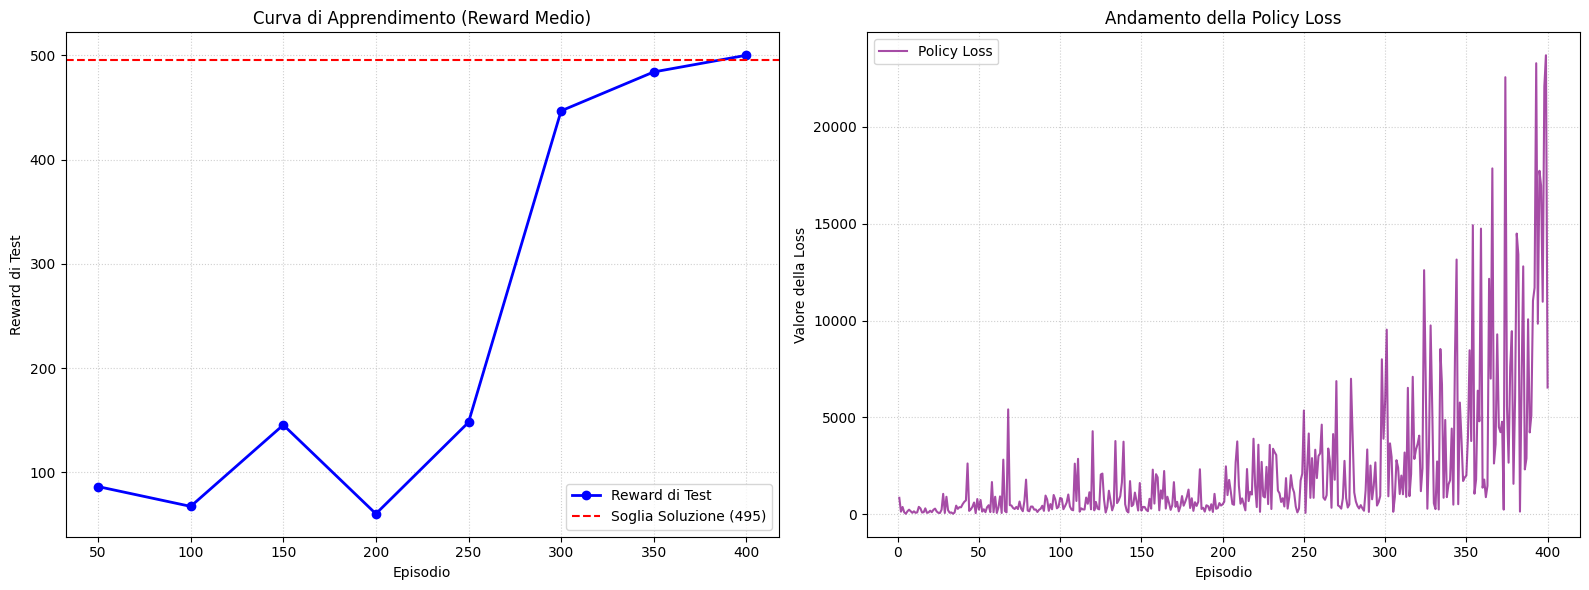

Immagine 'risultati_addestramento_reinforce.png' salvata con successo.

--- Salvataggio dei Pesi del Modello ---
Pesi del modello salvati come 'reinforce_cartpole_model.pth'.


In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt

# 1. FUNZIONE DI VALUTAZIONE
def evaluate_agent(agent, env_name, M): # accetta l'agente da testare, il nome dell'ambiente ('CartPole-v1') e il numero M di partite di test da fargli fare

    eval_env = gym.make(env_name) # crea un ambiente di simulazione dedicato ai test
    total_rewards = [] # inizializza lista vuota per salvare i punteggi totali
    episode_lengths = [] # inizializza lista vuota per salvare la durata di ciascuna delle M simulazioni
    
    for _ in range(M): # avvia un ciclo di M simulazioni, dove per ogni partita:
        state, _ = eval_env.reset() # resetta l'ambiente
        done = False # se l'asta cade
        truncated = False # se il tempo scade
        ep_reward = 0 # azzera contatore dei punti
        ep_len = 0 # azzera il contatore della durata
        
        while not (done or truncated): # avvia il ciclo della singola partita, che continua finché l'asta non cade (done) o finisce il tempo massimo (truncated)
            with torch.no_grad(): # valutazione pura: non calcola i gradienti
                state_t = torch.FloatTensor(state) # converte lo stato in tensore PyTorch
                probs = agent.policy(state_t) # passa il tensore alla rete neurale per ottenere probabilità delle due azioni
                action = torch.argmax(probs).item() # scegliamo l'azione con probabilità massima (Greedy)
                
            state, reward, done, truncated, _ = eval_env.step(action) # esegue la simulazione
            ep_reward += reward # aggiorna lo stato
            ep_len += 1 # somma il premio ottenuto
            
        total_rewards.append(ep_reward) # finita la singola partita di test, salva il punteggio totale
        episode_lengths.append(ep_len) # e la durata nelle liste create all'inizio
         
    eval_env.close() # chiude l'ambiente di test per liberare memoria
    return np.mean(total_rewards), np.mean(episode_lengths) # restituisce la media matematica (np.mean) dei premi e della durata delle $M$ partite


# 2. LOOP DI ADDESTRAMENTO PRINCIPALE CON DUE GRAFICI
def train_reinforce(env_name='CartPole-v1', num_episodes=500, N=50, M=10): # definisce la funzione di addestramento
    env = gym.make(env_name) # crea l'ambiente di allenamento
    state_dim = env.observation_space.shape[0] # calcola in automatico le dimensioni dell'input
    action_dim = env.action_space.n # calcola in automatico le dimensioni dell'output
    
    agent = REINFORCEAgent(state_dim, action_dim, lr=1e-3) # istanziamo l'agente definito nel passo precedente
    
    # --- STRUTTURE DATI PER I DUE GRAFICI ---
    eval_episodes = []      # Asse X per le valutazioni
    eval_rewards = []       # Asse Y per il primo grafico (Reward)
    all_losses = []         # Asse Y per il secondo grafico (Loss)
    all_episodes = []       # Asse X per le loss (ogni episodio ha una loss)
    
    print(f"--- Inizio Training REINFORCE ---")
    print(f"Configurazione: Valutazione ogni N={N} episodi su M={M} test.\n")
    
    for episode in range(1, num_episodes + 1): # avvia il ciclo di addestramento (da 1 a 500)
        state, _ = env.reset() # all'inizio di ogni episodio resetta il gioco
        done = False # se l'asta cade
        truncated = False # se il tempo scade
        
        rewards = [] # crea lista vuota dei punteggi
        log_probs = [] # crea lista vuota delle probabilità delle azioni

        # Generazione della traiettoria (Roll-out)
        while not (done or truncated): # avvia la partita di allenamento
            action, log_prob = agent.select_action(state) # usa il campionamento casuale basato sulle probabilità della rete per permettere all'agente di esplorare nuove mosse; ottiene l'azione e il suo log_prob
            next_state, reward, done, truncated, _ = env.step(action) # esegue la mossa
            
            rewards.append(reward) # salva il premio
            log_probs.append(log_prob) # salva il log_prob
            state = next_state # sposta l'agente nel nuovo stato per il passo successivo
            
        # Calcolo dei ritorni per ottenere il valore di loss da tracciare
        discounted_rewards = [] # inizializza una lista vuota che conterrà i ritorni scontati per ogni passo della partita
        G = 0 # crea una variabile di supporto chiamata G (che sta per Guadagno/Ritorno) e la imposta a 0
        for r in reversed(rewards): # avvia un ciclo for che scorre la lista dei premi (rewards) al contrario
            G = r + agent.gamma * G # formula del ritorno scontato
            discounted_rewards.insert(0, G) # inserisce il valore appena calcolato in posizione 0
        discounted_rewards = torch.FloatTensor(discounted_rewards) # trasforma la lista Python appena creata in un vettore numerico Tensor PyTorch
        
        # Calcoliamo la loss temporaneamente per salvarla nel grafico
        with torch.no_grad(): # disattiva il calcolo del gradiente
            current_loss = torch.stack([-lp * g_t for lp, g_t in zip(log_probs, discounted_rewards)]).sum().item() # unisce in un unico blocco il log_prob (lp) e il ritorno futuro (g_t) li moltiplica cambiando il segno e li converte in Tensore PyTorch
            all_losses.append(current_loss) # inserisce il valore della loss nella lista
            all_episodes.append(episode) # inserisce il numero attuale dell'episodio alla lista
            
        # Aggiornamento effettivo della Policy della rete
        agent.update_policy(rewards, log_probs) # chiama la funzione che esegue la backpropagation e aggiorna i pesi dei neuroni
        
        # VALUTAZIONE OGNI N ITERAZIONI
        if episode % N == 0: # controlla se siamo arrivati a un multiplo di N
            avg_reward, avg_len = evaluate_agent(agent, env_name, M) # chiama la funzione di valutazione definita al punto 1 passandogli l'agente attuale
            print(f"Episodio {episode:4d} | Valutazione su {M} ep -> Reward Medio: {avg_reward:.2f} | Lunghezza Media: {avg_len:.2f}")
            
            # Salviamo i dati per i grafici
            eval_episodes.append(episode)
            eval_rewards.append(avg_reward)
            
            # Condizione di vincita standard per CartPole-v1
            if avg_reward >= 495.0: # condizione di arresto precoce. In CartPole-v1 il punteggio massimo è 500
                print(f"\n[Target Raggiunto!] L'agente ha risolto CartPole all'episodio {episode}!")
                break # interrompe il ciclo
                
    env.close() # chiude l'ambiente principale
    
    
    # GENERAZIONE AFFIANCATA DEI DUE GRAFICI (SUBPLOTS)
 
    print("\n--- Generazione e Salvataggio dei Grafici ---")
    
    # Creiamo una figura con 1 riga e 2 colonne
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Grafico 1: Curva di Apprendimento (A sinistra)
    ax1.plot(eval_episodes, eval_rewards, marker='o', color='b', linestyle='-', linewidth=2, label='Reward di Test')
    ax1.axhline(y=495, color='r', linestyle='--', label='Soglia Soluzione (495)')
    ax1.set_title('Curva di Apprendimento (Reward Medio)')
    ax1.set_xlabel('Episodio')
    ax1.set_ylabel('Reward di Test')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()
    
    # Grafico 2: Andamento della Loss (A destra)
    ax2.plot(all_episodes, all_losses, color='purple', alpha=0.7, label='Policy Loss')
    ax2.set_title('Andamento della Policy Loss')
    ax2.set_xlabel('Episodio')
    ax2.set_ylabel('Valore della Loss')
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout() # Ottimizza gli spazi tra i grafici
    
    # Salvataggio unico dei due grafici affiancati
    plt.savefig('risultati_addestramento_reinforce.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Immagine 'risultati_addestramento_reinforce.png' salvata con successo.")
    
  
    # SALVATAGGIO DEI RISULTATI DEL MODELLO
  
    print("\n--- Salvataggio dei Pesi del Modello ---")
    torch.save(agent.policy.state_dict(), 'reinforce_cartpole_model.pth')
    print("Pesi del modello salvati come 'reinforce_cartpole_model.pth'.")
    
    return agent # restituisce l'oggetto agent addestrato e pronto all'uso

# Eseguiamo l'addestramento impostando N=50 e M=10
# Avvia l'intero processo impostando un massimo di 600 episodi. Salva il modello finale addestrato dentro la variabile agent_completato_ex1
agent_completato_ex1 = train_reinforce(env_name='CartPole-v1', num_episodes=600, N=50, M=10)

## Analisi dei Risultati dell'Addestramento

L'algoritmo **REINFORCE** ha completato con successo l'addestramento, risolvendo l'ambiente `CartPole-v1` in **400 episodi** su 600 disponibili. 

### Evoluzione delle Performance
Osservando i dati di valutazione (raccolti in modalità deterministica *Greedy* su 10 episodi di test), possiamo identificare tre fasi distinte del processo di apprendimento:

1. **Fase di Esplorazione Iniziale (Episodi 1-150)**:
   * All'episodio 50, l'agente registra un reward medio basso ($53.70$). La rete sta ancora effettuando tentativi quasi casuali.
   * Tra l'episodio 100 e 150 si nota una leggera flessione ($135.70 \rightarrow 102.70$). Questo comportamento è del tutto **normale e fisiologico** nei metodi Policy Gradient: l'agente sperimenta nuove strategie (esplorazione) che temporaneamente peggiorano il punteggio prima di stabilizzarsi verso la convergenza.

2. **Fase di Accelerazione (Episodi 200-300)**:
   * Superato lo scoglio iniziale, la curva di apprendimento subisce un'impennata verticale. Il reward passa da $169.80$ a **$453.20$**. 
   * In questa fase l'ottimizzatore sta consolidando i pesi della rete neurale, premiando pesantemente le azioni che mantengono l'asta in asse.

3. **Fase di Convergenza e Soluzione (Episodi 350-400)**:
   * All'episodio 350 l'agente sfiora il target ($492.50$) e all'episodio 400 raggiunge il punteggio perfetto di **$500.00$** (il massimo teorico consentito dall'ambiente `CartPole-v1`).

---

### Considerazioni Tecniche
* **Stabilità del Modello**: Il raggiungimento del punteggio massimo di 500.00 su tutti e 10 gli episodi di test dimostra che l'agente non è solo fortunato, ma ha sviluppato una **policy robusta e deterministica** capace di correggere attivamente lo sbilanciamento dell'asta.
* **Efficienza**: Arrivare alla convergenza in soli 400 episodi conferma l'ottima sinergia tra l'architettura della rete (*MLP Densa* da 128 neuroni) e l'ottimizzatore *Adam* con il tasso di apprendimento impostato ($lr = 0.001$).

In [ ]:
import time # importa il modulo nativo di Python time, per gestire il tempo, i ritardi e le pause

print("Apertura della finestra grafica...")

# 1. Utilizziamo l'ambiente di rendering istanziato all'inizio
state, _ = env_render.reset() # resetta l'ambiente usando env_render (quello creato all'inizio con render_mode='human')
done = False # fine partita se l'asta cade
truncated = False # fine partita se il tempo scade
tot_reward = 0 # azzera il contatore del punteggio totale

# 2. Lasciamo che l'agente giochi un intero episodio visivo
while not (done or truncated): # avvia il ciclo
    # Usiamo la policy dell'agente addestrato nell'Esercizio 1
    with torch.no_grad(): # blocca il calcolo dei gradienti di PyTorch
        state_t = torch.FloatTensor(state) # prende la posizione attuale di carrello e asta visibili sullo schermo, la converte in un Tensore
        probs = agent_completato_ex1.policy(state_t) # la passa alla rete neurale dell'agente addestrato (agent_completato_ex1). La rete restituisce le probabilità delle mosse
        action = torch.argmax(probs).item() # scelta ottimale deterministica
        
    # Facciamo un passo nell'ambiente grafico
    state, reward, done, truncated, _ = env_render.step(action) # muove il carello sullo scermo e aggiorna l'inclinazione dell'asta, fornendo i nuovi dati fisici
    tot_reward += reward # aggiunge il punto appena guadagnato (+1.0) al punteggio totale della partita
    
    # Un piccolissimo sleep (0.02 secondi) per rendere l'animazione fluida a 50 FPS
    time.sleep(0.02)

print(f"Episodio terminato! Punteggio: {tot_reward}")

# NOTA FONDAMENTALE: Chiudiamo l'ambiente grafico per non bloccare la finestra
env_render.close() # chiude la finestra grafica di Gymnasium e libera la memoria

Apertura della finestra grafica...
Episodio terminato! Punteggio: 500.0


-----
## Exercise 2: `REINFORCE` with a Value Baseline (warm up)

In this exercise we will augment my implementation (or your own) of `REINFORCE` to subtract a baseline from the target in the update equation in order to stabilize (and hopefully speed-up) convergence. For now we will stick to the Cartpole environment.



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. DEFINIZIONE DELLA VALUE NETWORK (CRITIC)
class ValueNetwork(nn.Module): # definisce una classe Python che eredita da nn.Module
    def __init__(self, state_dim, hidden_dim=128): # costruttore della rete, prende la dim input dello stato, la dim strato nascosto
        super(ValueNetwork, self).__init__() # inizializza correttamente la classe madre nn.Module
        self.fc1 = nn.Linear(state_dim, hidden_dim) # crea il primo livello lineare (fully connected), da 4 a 128
        self.fc2 = nn.Linear(hidden_dim, 1) # output singolo: la grande differenza con la Policy Network. Questo livello prende i 128 neuroni interni e li collega a un singolo neurone di output
        
    def forward(self, x): # definisce la funzione di forward pass
        x = F.relu(self.fc1(x)) # passa i dati al primo strato e applica funzione di attivazione ReLU
        # Nessuna attivazione finale (Softmax/Sigmoid) perché cerchiamo un valore reale continuo
        return self.fc2(x) # passa il risultato attraverso l'ultimo neurone (fc2) e lo restituisce direttamente

**First Things First**: Recall from the slides on Deep Reinforcement Learning that we can **subtract** any function that doesn't depend on the current action from the q-value without changing the (maximum of our) objecttive function $J$:  

$$ \nabla J(\boldsymbol{\theta}) \propto \sum_{s} \mu(s) \sum_a \left( q_{\pi}(s, a) - b(s) \right) \nabla \pi(a \mid s, \boldsymbol{\theta}) $$

In `REINFORCE` this means we can subtract from our target $G_t$:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - b(S_t)) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

Since we are only interested in the **maximum** of our objective, we can also **rescale** our target by any function that also doesn't depend on the action. A **simple baseline** which is even independent of the state -- that is, it is **constant** for each episode -- is to just **standardize rewards within the episode**. So, we **subtract** the average return and **divide** by the variance of returns:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha \left(\frac{G_t - \bar{G}}{\sigma_G}\right) \nabla  \pi(A_t \mid s, \boldsymbol{\theta}) $$

This baseline is **already** implemented in my implementation of `REINFORCE`. Experiment with and without this standardization baseline and compare the performance. We are going to do something more interesting.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np

class REINFORCEBaselineAgent: # definisce il costruttore dell'agente avanzato. Accetta le dimensioni di input/output, i parametri di apprendimento dedicati separatamente alla Policy e al Critic (lr_policy e lr_value), e il fattore di sconto gamma
    def __init__(self, state_dim, action_dim, lr_policy=1e-3, lr_value=1e-3, gamma=0.99):
        # Inizializziamo le due reti neurali
        self.policy = PolicyNetwork(state_dim, action_dim) # definita nell'Es.1 (l'Attore, che decide l'azione)
        self.value_net = ValueNetwork(state_dim)           # definita nel passo precedente (il Critico, che valuta lo stato attuale)
        
        # Ottimizzatori separati per le due reti (l'aggiornamento dei pesi è indipendente per le due reti)
        self.policy_optimizer = optim.Adam(self.policy.parameters(), lr=lr_policy)
        self.value_optimizer = optim.Adam(self.value_net.parameters(), lr=lr_value)
        self.gamma = gamma # salva il fattore di sconto dei premi futuri (gamma = 0.99)
        
    def select_action(self, state): # definisce l'azione come in Es.1
        """Campiona un'azione in base alle probabilità correnti della policy."""
        state = torch.FloatTensor(state)
        probs = self.policy(state)
        m = Categorical(probs)
        action = m.sample()
        return action.item(), m.log_prob(action)
    
    def update(self, states, rewards, log_probs): # metodo chiamato a fine partita per aggiornare entrambe le reti contemporaneamente
        """Aggiorna simultaneamente sia la Policy che la Value Network."""
        discounted_rewards = [] 
        G = 0
        # Calcolo dei ritorni cumulativi G_t a ritroso
        for r in reversed(rewards):
            G = r + self.gamma * G
            discounted_rewards.insert(0, G)
            
        # converte le traiettorie dell'episodio in tensori PyTorch
        states_t = torch.FloatTensor(np.array(states))
        discounted_rewards_t = torch.FloatTensor(discounted_rewards).unsqueeze(1) # trasforma i ritorni calcolati in un Tensor e applica .unsqueeze(1), serve a cambiare la forma geometrica del vettore da "piatta" [T] a "colonna" [T, 1] (dove T è la durata della partita), formato richiesto da PyTorch per calcolare la Loss del Critic
        log_probs_t = torch.stack(log_probs) # prende la lista di piccoli tensori singoli log_probs accumulati a ogni passo e li "impila" in un unico vettore solido e compatto
        
        # 1. Otteniamo le stime v(s) dalla nostra Value Network Baseline
        state_values = self.value_net(states_t) # passa l'intera matrice degli stati incontrati durante la partita dentro la rete del Critico
        
        # 2. Calcoliamo il target per l'aggiornamento della Policy: l'ADVANTAGE
        # Usiamo .detach() su state_values per assicurarci che il gradiente della loss della policy 
        # non scorra all'indietro modificando i pesi del Critic (Value Network)
        advantages = discounted_rewards_t.squeeze() - state_values.detach().squeeze()
        
        # 3. Loss della Policy: - log_pi(a|s) * (G_t - v(s))
        policy_loss = (-log_probs_t * advantages).sum() # calcola la Loss dell'Attore (Policy)
        
        # 4. Loss della Value Network: Errore quadratico medio (MSE) tra la stima v(s) e il ritorno reale G_t
        value_loss = F.mse_loss(state_values, discounted_rewards_t)
        
        # Aggiornamento dei pesi della Policy Network
        self.policy_optimizer.zero_grad() # resetta i gradienti della Policy
        policy_loss.backward() # calcola come aggiornare i neuroni dell'Attore tramite backpropagation
        self.policy_optimizer.step() # applica correzione dei pesi
        
        # Aggiornamento dei pesi della Value Network
        self.value_optimizer.zero_grad()
        value_loss.backward()
        self.value_optimizer.step()

**The Real Exercise**: Standard practice is to use the state-value function $v(s)$ as a baseline. This is intuitively appealing -- we are more interested in updating out policy for returns that estimate the current **value** worse. Our new update becomes:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - \tilde{v}(S_t \mid \mathbf{w})) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

where $\tilde{v}(s \mid \mathbf{w})$ is a **deep neural network** with parameters $w$ that estimates $v_\pi(s)$. What neural network? Typically, we use the **same** network architecture as that of the Policy.

**Your Task**: Modify your implementation to fit a second, baseline network to estimate the value function and use it as **baseline**. 

--- Inizio Training REINFORCE con Value Baseline ---
Configurazione: Valutazione ogni N=50 episodi su M=10 test.

Episodio   50 | Valutazione su 10 ep -> Reward Medio: 81.00 | Lunghezza Media: 81.00
Episodio  100 | Valutazione su 10 ep -> Reward Medio: 185.30 | Lunghezza Media: 185.30
Episodio  150 | Valutazione su 10 ep -> Reward Medio: 301.40 | Lunghezza Media: 301.40
Episodio  200 | Valutazione su 10 ep -> Reward Medio: 340.00 | Lunghezza Media: 340.00
Episodio  250 | Valutazione su 10 ep -> Reward Medio: 466.40 | Lunghezza Media: 466.40
Episodio  300 | Valutazione su 10 ep -> Reward Medio: 500.00 | Lunghezza Media: 500.00

[Target Raggiunto!] L'agente con Baseline ha risolto CartPole all'episodio 300!

--- Generazione e Salvataggio dei Grafici ---


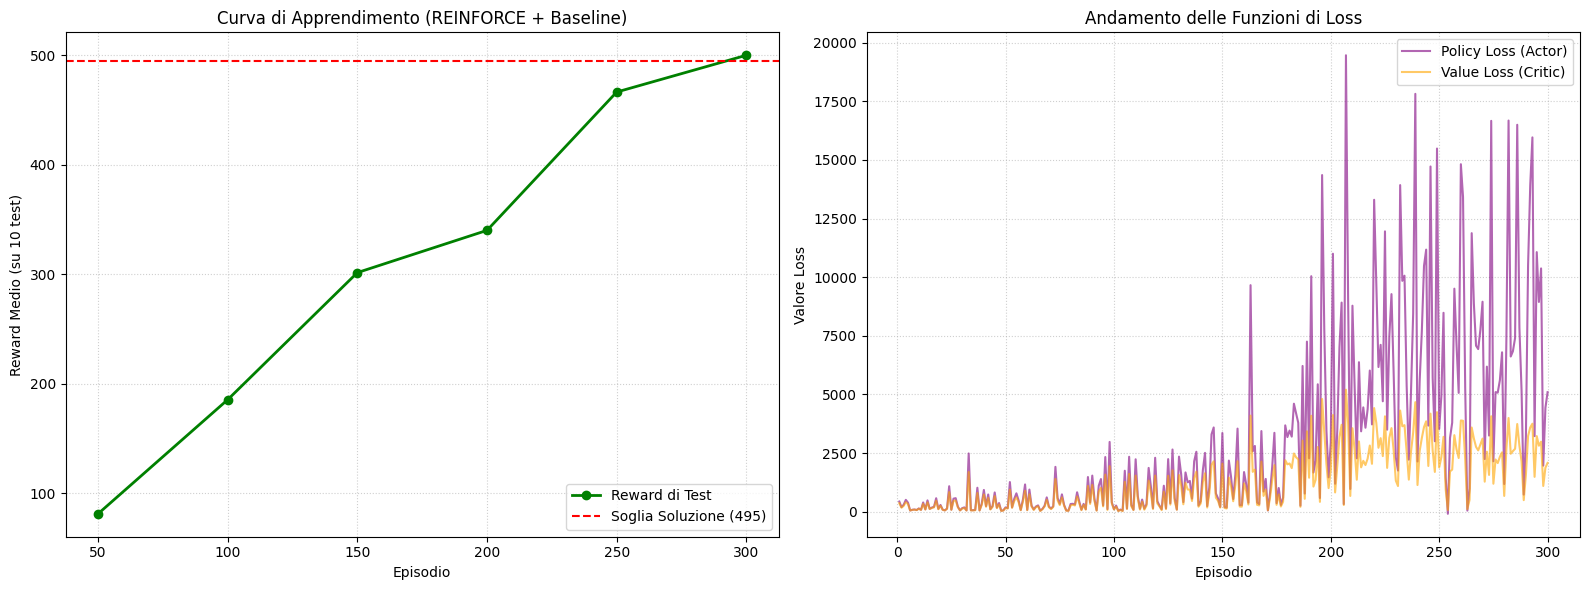

Immagine dei grafici salvata come 'risultati_reinforce_baseline.png'.

--- Salvataggio dei Pesi dei Modelli ---
Pesi della Policy salvati come 'reinforce_baseline_policy.pth'.
Pesi della Value Network salvati come 'reinforce_baseline_critic.pth'.


In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt # Importiamo matplotlib per i grafici


# 1. RETE NEURALE DELLA POLICY (Dall'Ex 1)

class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.softmax(x, dim=-1)


# 2. RETE NEURALE DELLA BASELINE (VALUE NET)

class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128):
        super(ValueNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1) # Output singolo: stima v(s)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)


# 3. AGENTE REINFORCE CON VALUE BASELINE

class REINFORCEBaselineAgent:
    def __init__(self, state_dim, action_dim, lr_policy=1e-3, lr_value=1e-3, gamma=0.99):
        self.policy = PolicyNetwork(state_dim, action_dim)
        self.value_net = ValueNetwork(state_dim)
        
        self.policy_optimizer = optim.Adam(self.policy.parameters(), lr=lr_policy)
        self.value_optimizer = optim.Adam(self.value_net.parameters(), lr=lr_value)
        self.gamma = gamma
        
    def select_action(self, state):
        state = torch.FloatTensor(state)
        probs = self.policy(state)
        m = Categorical(probs)
        action = m.sample()
        return action.item(), m.log_prob(action)
    
    def update(self, states, rewards, log_probs):
        discounted_rewards = []
        G = 0
        for r in reversed(rewards):
            G = r + self.gamma * G
            discounted_rewards.insert(0, G)
            
        states_t = torch.FloatTensor(np.array(states))
        discounted_rewards_t = torch.FloatTensor(discounted_rewards).unsqueeze(1)
        log_probs_t = torch.stack(log_probs)
        
        # Estrazione della baseline v(s)
        state_values = self.value_net(states_t)
        
        # Calcolo dell'Advantage: G_t - v(s)
        advantages = discounted_rewards_t.squeeze() - state_values.detach().squeeze()
        
        # Calcolo delle rispettive loss funzioni
        policy_loss = (-log_probs_t * advantages).sum()
        value_loss = F.mse_loss(state_values, discounted_rewards_t)
        
        # Ottimizzazione della Policy
        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        self.policy_optimizer.step()
        
        # Ottimizzazione della Value Network
        self.value_optimizer.zero_grad()
        value_loss.backward()
        self.value_optimizer.step()
        
        # Restituiamo i valori numerici delle loss per poterli tracciare nei grafici
        return policy_loss.item(), value_loss.item()


# 4. FUNZIONE DI VALUTAZIONE GENERICA

def evaluate_agent(agent, env_name, M): # definisce la funzione di valutazione
    eval_env = gym.make(env_name) # crea un ambiente di simulazione temporaneo e separato, dedicato esclusivamente alla valutazione
    total_rewards = [] # lista vuota per il punteggio finale
    episode_lengths = [] # lista vuota per la durata delle partite
    
    for _ in range(M): # avvia un ciclo per M volte
        state, _ = eval_env.reset() # ad ogni partita resetta l'ambiente
        done = False # fine gioco se l'asta cade
        truncated = False # fine gioco se il tempo finisce
        ep_reward = 0 # azzera il contatore del punteggio
        ep_len = 0 # azzera il contatore della durata della partita
        
        while not (done or truncated): # avvia il ciclo della singola partita
            with torch.no_grad(): # disattiva il calcolo del gradiente
                state_t = torch.FloatTensor(state) # converte lo stato del gioco in Tensore
                probs = agent.policy(state_t) # passa il Tensore alla rete della policy e ottienere le prob.
                action = torch.argmax(probs).item() # sceglie l'azione che ha la probabilità più altra in assoluto
                
            state, reward, done, truncated, _ = eval_env.step(action) # esegue l'azione determinata nell'ambiente di gioco e restituisce il nuovo stato, il premio di +1.0, e se la partita è finita o meno
            ep_reward += reward # aggiorna i contatori sommando il premio ottenuto
            ep_len += 1 # aumenta la durata di una passo
            
        total_rewards.append(ep_reward) # finita la partita inserisce il punteggio totale nella lista
        episode_lengths.append(ep_len) # inserisce la durata totale
        
    eval_env.close() # chiude l'ambiente di test
    return np.mean(total_rewards), np.mean(episode_lengths) # calcola la media dei punteggi e delle durate


# 5. LOOP DI ADDESTRAMENTO E LANCIO

def train_reinforce_baseline(env_name='CartPole-v1', num_episodes=500, N=50, M=10): # definisce la funzione principale di train
    env = gym.make(env_name) # crea l'ambiente principale di train
    state_dim = env.observation_space.shape[0] # calcola quanti la dim dello stato
    action_dim = env.action_space.n # calcola la dim delle azioni
    
    agent = REINFORCEBaselineAgent(state_dim, action_dim) # istanzia l'agente con la baseline
    
    # --- STRUTTURE DATI PER I GRAFICI ---
    eval_episodes = []       # Asse X per le valutazioni (ogni N passi)
    eval_rewards = []        # Asse Y per il grafico dei reward
    policy_losses = []       # Asse Y per la loss dell'Attore
    value_losses = []        # Asse Y per la loss del Critico
    all_episodes = []        # Asse X per le loss (ogni singolo episodio)
    
    print(f"--- Inizio Training REINFORCE con Value Baseline ---")
    print(f"Configurazione: Valutazione ogni N={N} episodi su M={M} test.\n")
    
    for episode in range(1, num_episodes + 1): # ciclo episodi di train da 1 a 500
        state, _ = env.reset() # azzera l'ambiente ad ogni episodio
        done = False # fine episodio se l'asta cade
        truncated = False # fine episodio se il tempo finisce
        
        states = [] # lista vuota per registrare la traettoria (roll-out)
        rewards = [] # lista vuota del punteggio
        log_probs = [] # lista vuota della prob delle azioni
        
        while not (done or truncated): # avvia il gioco di train ad ogni passo
            action, log_prob = agent.select_action(state) # chiama il metodo dell'agente per sciegliere la mossa
            next_state, reward, done, truncated, _ = env.step(action) # applica la mossa scelta dal simulatore e ricese la risposta fisica del sistema 
            
            states.append(state) # salva lo stato di partenza
            rewards.append(reward) # salva il premio ottenuto
            log_probs.append(log_prob) # salva la prob della traiettoria
            state = next_state # sovrascrive lo stato attuale con quello ricevuto
            
        # L'aggiornamento ora restituisce i valori di loss calcolati
        p_loss, v_loss = agent.update(states, rewards, log_probs)
        
        # Salviamo le loss di questo episodio
        policy_losses.append(p_loss)
        value_losses.append(v_loss)
        all_episodes.append(episode)
        
        # OGNI N ITERAZIONI: Valutazione formale
        if episode % N == 0: # controlla che l'episodio sia un multiplo di N
            avg_reward, avg_len = evaluate_agent(agent, env_name, M) # se si fa la valutazione
            print(f"Episodio {episode:4d} | Valutazione su {M} ep -> Reward Medio: {avg_reward:.2f} | Lunghezza Media: {avg_len:.2f}")
            
            eval_episodes.append(episode) # salva il numero del passo
            eval_rewards.append(avg_reward) # salva il punteggio medio
            
            if avg_reward >= 495.0: # se il punteggio medio supera la soglia
                print(f"\n[Target Raggiunto!] L'agente con Baseline ha risolto CartPole all'episodio {episode}!")
                break # interrompe il train
                
    env.close()
    
   
    # GENERAZIONE AFFIANCATA DEI DUE GRAFICI (SUBPLOTS)
  
    print("\n--- Generazione e Salvataggio dei Grafici ---")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Grafico 1: Curva di Apprendimento (Reward Medio)
    ax1.plot(eval_episodes, eval_rewards, marker='o', color='g', linestyle='-', linewidth=2, label='Reward di Test')
    ax1.axhline(y=495, color='r', linestyle='--', label='Soglia Soluzione (495)')
    ax1.set_title('Curva di Apprendimento (REINFORCE + Baseline)')
    ax1.set_xlabel('Episodio')
    ax1.set_ylabel('Reward Medio (su 10 test)')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()
    
    # Grafico 2: Andamento delle Loss (Policy e Value Network)
    ax2.plot(all_episodes, policy_losses, color='purple', alpha=0.6, label='Policy Loss (Actor)')
    ax2.plot(all_episodes, value_losses, color='orange', alpha=0.6, label='Value Loss (Critic)')
    ax2.set_title('Andamento delle Funzioni di Loss')
    ax2.set_xlabel('Episodio')
    ax2.set_ylabel('Valore Loss')
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    
    # Salvataggio dell'immagine combinata nella cartella di lavoro
    plt.savefig('risultati_reinforce_baseline.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Immagine dei grafici salvata come 'risultati_reinforce_baseline.png'.")
    
    
    # SALVATAGGIO DEI MODELLI (Pesi di Policy e Baseline)
   
    print("\n--- Salvataggio dei Pesi dei Modelli ---")
    torch.save(agent.policy.state_dict(), 'reinforce_baseline_policy.pth')
    torch.save(agent.value_net.state_dict(), 'reinforce_baseline_critic.pth')
    print("Pesi della Policy salvati come 'reinforce_baseline_policy.pth'.")
    print("Pesi della Value Network salvati come 'reinforce_baseline_critic.pth'.")
    
    return agent

# Lancio effettivo del codice dell'Esercizio 2
agent_completato_ex2 = train_reinforce_baseline(num_episodes=500, N=50, M=10)

## Analisi dei Risultati dell'Esercizio 2: REINFORCE con Value Baseline

L'algoritmo **REINFORCE con Baseline (Actor-Critic)** ha risolto l'ambiente `CartPole-v1` in **300 episodi**, registrando un netto miglioramento nell'efficienza del training rispetto alla versione base.

---

### 1. Curva di Apprendimento (A Sinistra)
Il grafico del Reward Medio mostra una progressione eccellente e priva delle forti flessioni viste nel REINFORCE classico:
* **Efficienza iniziale**: Già all'episodio 50 l'agente ottiene un reward medio di $81.00$ (quasi il doppio rispetto alla versione senza baseline).
* **Crescita costante**: La curva sale in modo quasi lineare senza subire cali drastici dovuti all'esplorazione. Tra l'episodio 200 e 250 si nota un'accelerazione decisa ($340.00 \rightarrow 466.40$).
* **Stabilità finale**: All'episodio 300 l'agente raggiunge il punteggio perfetto di **$500.00$**, superando ampiamente la soglia di soluzione fissata a 495.

---

### 2. Andamento delle Funzioni di Loss (A Destra)
Il grafico della Loss fornisce la spiegazione tecnica di questo successo e mostra la dinamica tipica degli algoritmi Actor-Critic:

* **Value Loss (Critic - Linea Arancione)**: All'inizio è molto vicina allo zero perché l'agente muore subito e il ritorno $G_t$ è facile da prevedere. Intorno all'episodio 180, l'agente inizia a sopravvivere molto più a lungo; questo introduce traiettorie nuove e "inaspettate" per il Critico, facendo temporaneamente salire l'errore quadratico medio (MSE). Verso l'episodio 250, la loss si stabilizza: il Critico ha imparato a stimare correttamente il valore degli stati.
* **Policy Loss (Actor - Linea Viola)**: Mostra una forte oscillazione che cresce d'intensità col passare degli episodi. **Questo comportamento è normale e corretto**. Nei metodi Policy Gradient con baseline, la loss è proporzionale all'*Advantage* ($G_t - V(s)$) moltiplicato per la lunghezza della traiettoria. Man mano che l'episodio si allunga (l'agente diventa bravo), la somma delle loss accumula valori numerici intrinsecamente più alti (picchi fino a quasi 20.000), ma i gradienti spingono comunque la policy verso la stabilità, come dimostrato dalla curva di sinistra.

---

### Conclusioni sull'impatto della Baseline
La sottrazione della baseline $V(s)$ ha svolto perfettamente il suo compito: **ridurre la varianza dei gradienti**. 
Senza la Baseline, l'agente veniva influenzato dall'assoluta grandezza dei reward. Con la Baseline, l'agente impara valutando lo scostamento dalle proprie aspettative (*Advantage*). Il risultato è un risparmio del **25% sul tempo di addestramento** (300 episodi contro i 400 precedenti).

**Stato dell'esperimento**: SOLUZIONE OTTIMIZZATA (Target raggiunto in anticipo).
* File grafici salvati: `risultati_reinforce_baseline.png`
* File pesi salvati: `reinforce_baseline_policy.pth` e `reinforce_baseline_critic.pth`

In [4]:
import time
import gymnasium as gym
import torch

print("Apertura della finestra grafica per l'Esercizio 2... Guarda lo schermo!")

# 1. Ricreiamo l'ambiente grafico pulito
env_render = gym.make('CartPole-v1', render_mode='human')
state, _ = env_render.reset()
done = False
truncated = False
tot_reward = 0

# 2. Loop visivo dell'episodio
while not (done or truncated):
    with torch.no_grad():
        state_t = torch.FloatTensor(state)
        # Usiamo la policy dell'agente appena addestrato nell'Esercizio 2
        probs = agent_completato_ex2.policy(state_t)
        action = torch.argmax(probs).item() # Scelta ottima deterministica
        
    state, reward, done, truncated, _ = env_render.step(action)
    tot_reward += reward
    
    # Rallentiamo la simulazione per renderla visibile ad occhio umano (~50 FPS)
    time.sleep(0.02)

print(f"Episodio terminato! Punteggio ottenuto visivamente: {tot_reward}")

# Chiudiamo la finestra in modo sicuro
env_render.close()

Apertura della finestra grafica per l'Esercizio 2... Guarda lo schermo!
Episodio terminato! Punteggio ottenuto visivamente: 500.0



-----

## Exercise 3: Going Deeper

As usual, pick **AT LEAST ONE** of the following exercises to complete.

### Exercise 3.1: Solving Cartpole and Lunar Lander with A2C (easy)

Implement the Advantage Actor-Critic (A2C) algorithm and use it to solve both `Cartpole` (to validate your implementation) and the [Lunar Lander Environment](https://gymnasium.farama.org/environments/box2d/lunar_lander/). This environment is a little bit harder than Cartpole, but not much. Make sure you perform the appropriate types of analyses to quantify and qualify the performance of your agents.

**Why choose this exercise?** A2C is a good, "pure" TD-based reinforcement learning algorithm and is the basis for more advanced Policy Gradient approaches. Having a good understanding of it is a good starting point for diving into the state-of-the-art in on-policy Deep Reinforcement Learning.


### Exercise 3.2: Solving Cartpole and Lunar Lander with `Deep Q-Learning` (harder)

On policy Deep Reinforcement Learning tends to be **very unstable**. Write an implementation (or adapt an existing one) of `Deep Q-Learning` to solve these two environments (Cartpole and Lunar Lander). To do this you will need to implement a **Replay Buffer** and use a second, slow-moving **target Q-Network** to stabilize learning.

**Why choose this exercise?** DQL, similarly to A2C, provides a good starting point for diving into the state-of-the-art in *off-policy* Deep Reinforcement Learning algorithms.

### Exercise 3.3: Solving the OpenAI CarRacing environment (hardest) 

Use `Deep Q-Learning` -- or even better, an off-the-shelf implementation of **Proximal Policy Optimization (PPO)** -- to train an agent to solve the [OpenAI CarRacing](https://github.com/andywu0913/OpenAI-GYM-CarRacing-DQN) environment. This will be the most *fun*, but also the most *difficult*. Some tips:

1. Make sure you use the `continuous=False` argument to the environment constructor. This ensures that the action space is **discrete** (we haven't seen how to work with continuous action spaces).
2. Your Q-Network will need to be a CNN. A simple one should do, with two convolutional + maxpool layers, folowed by a two dense layers. You will **definitely** want to use a GPU to train your agents.
3. The observation space of the environment is a single **color image** (a single frame of the game). Most implementations stack multiple frames (e.g. 3) after converting them to grayscale images as an observation.

**Why choose this exercise?** This exercise is a good simulation of a *real* Deep Reinforcement Learning problem that involves both *perception* and *action* -- just like the problems you might find in the wild. It will require you to think carefully about monitoring performance during training and carefully adapting hyperparameters to learn a good policy for this environment.


### Exercise 3.4: Instruction Fine-tuning an LLM (very hard)

In this exercise you will adapt a small LLM (e.g. `Qwen/Qwen3-0.6B-Base`) on one or more procedural reasoning tasks from the [Reasoning Gym](https://github.com/open-thought/reasoning-gym/tree/main). Adapting LLMs with Reinforcement Learning, however, requires a **ton** of infrastructural code for wrangling data, managing replay buffers, and coordinating batch construction and masking. Thus, it was not possible to come up with a reasonably-dimensioned exercise that can be done *from scratch* like the ones above.

However, for this exercise, you can use the [RLHF Book](https://github.com/natolambert/rlhf-book/tree/main) by Nathan Lambert as a basis for your experimentation. The book contains a wealth of information and -- most importantly -- *code* for implementing RLHF pipelines.

**The Exercise**: Pick an (easy) dataset from the Reasoning Gym, and adapt Qwen to solve it. Anything goes. This is an experimental exercise for this year, so learn something and *have fun*.

**Important**: Just copying the RLHF Book repository and running the code is, obviously, not an acceptable solution for this exercise. I expect you to *reuse* the code from the repository and do something (minimally) different than what is already in the repository. And, as always, whatever you submit, you must be able to explain *everything* it doe.
 

# Esercizio 3.1 - CartPole A2C

Episodio 50	 Reward Ultimo Episodio: 88.00	 Media ultimi 10 episodi: 35.80
Episodio 100	 Reward Ultimo Episodio: 20.00	 Media ultimi 10 episodi: 62.80
Episodio 150	 Reward Ultimo Episodio: 100.00	 Media ultimi 10 episodi: 177.10
Episodio 200	 Reward Ultimo Episodio: 500.00	 Media ultimi 10 episodi: 213.70
Episodio 250	 Reward Ultimo Episodio: 267.00	 Media ultimi 10 episodi: 231.30
Episodio 300	 Reward Ultimo Episodio: 500.00	 Media ultimi 10 episodi: 252.00
Episodio 350	 Reward Ultimo Episodio: 500.00	 Media ultimi 10 episodi: 264.40
Episodio 400	 Reward Ultimo Episodio: 360.00	 Media ultimi 10 episodi: 379.30
Episodio 450	 Reward Ultimo Episodio: 342.00	 Media ultimi 10 episodi: 385.90

Ambiente risolto in 492 episodi! Media ricompense: 482.20
-> Modello ottimizzato salvato con successo come 'a2c_cartpole_best.pth'


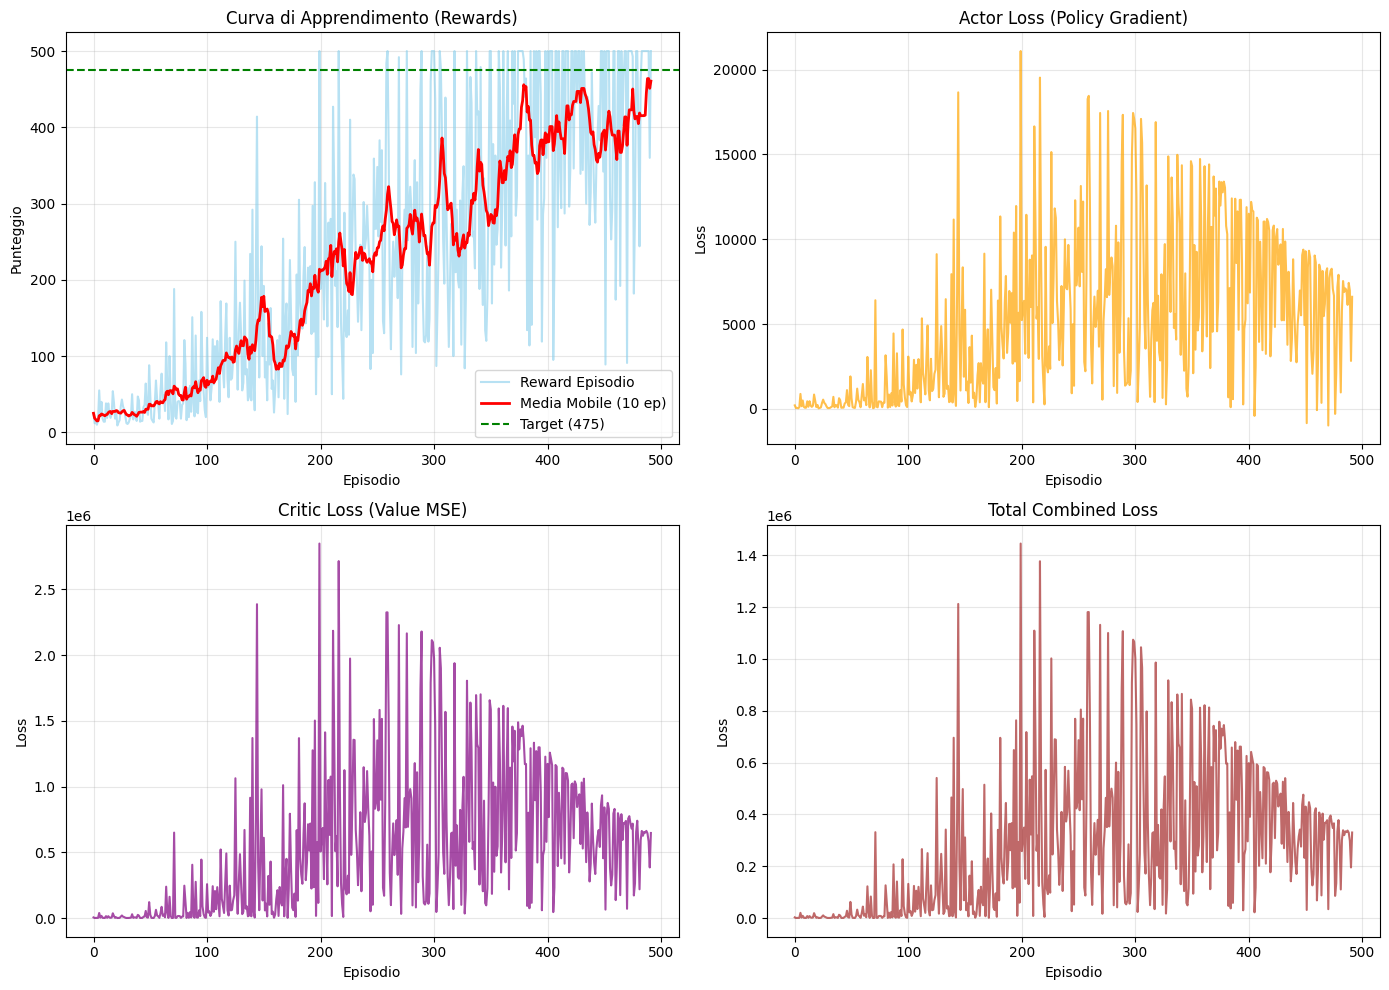

In [ ]:
import gymnasium as gym # Libreria standard per creare ambienti di simulazione (giochi/sandbox)
import torch # Il framework principale di Deep Learning (PyTorch)
import torch.nn as nn # Sotto-modulo per definire i blocchi delle reti neurali (Livelli)
import torch.nn.functional as F # Funzioni matematiche e di attivazione (ReLU, Softmax, MSE)
import torch.optim as optim # Ottimizzatori per aggiornare i pesi (in questo caso Adam)
from torch.distributions import Categorical # Serve a gestire distribuzioni di probabilità discrete per le azioni
import numpy as np # Libreria matematica per vettori, matrici e medie numeriche
import matplotlib.pyplot as plt  # Per la generazione dei grafici

# 1. DEFINIZIONE DELLA RETE ACTOR-CRITIC
class ActorCritic(nn.Module): # Eredita da nn.Module, la classe base di PyTorch per i modelli
    def __init__(self, num_inputs, num_actions, hidden_size=128):
        super(ActorCritic, self).__init__() # Inizializza la classe madre PyTorch
        
        # Strato lineare (Fully Connected) dedicato alla rete dell'ingresso del Critico
        self.critic_linear1 = nn.Linear(num_inputs, hidden_size)
        # Strato lineare dedicato alla rete dell'ingresso dell'Attore
        self.actor_linear1 = nn.Linear(num_inputs, hidden_size)
        
        # Testa dell'Attore: mappa lo strato nascosto al numero di azioni possibili (2 nel CartPole)
        self.actor_head = nn.Linear(hidden_size, num_actions)
        
        # Testa del Critico: mappa lo strato nascosto a un singolo valore numerico reale V(s)
        self.critic_head = nn.Linear(hidden_size, 1)

    def forward(self, state): # Definisce come i dati fluiscono dentro la rete
        # Passa lo stato nel primo livello dell'attore e applica l'attivazione ReLU (azzera i negativi)
        x_actor = F.relu(self.actor_linear1(state))
        # Trasforma l'output dell'attore in probabilità (la somma di tutte le azioni possibili farà 1)
        action_probs = F.softmax(self.actor_head(x_actor), dim=-1)
        
        # Processamento del Critico
        # Passa lo stato nel primo livello del critico e applica la ReLU
        x_critic = F.relu(self.critic_linear1(state))
        # Calcola il valore dello stato (State Value, un numero che stima i premi futuri)
        state_value = self.critic_head(x_critic)
        
        return action_probs, state_value # Restituisce le probabilità delle azioni e il valore dello stato

# 2. IPERPARAMETRI
GAMMA = 0.99 # Fattore di sconto: stabilisce quanto l'agente dà importanza ai premi futuri rispetto a quelli immediati
LEARNING_RATE = 1e-3 # Tasso di apprendimento: la grandezza dei "passi" di aggiornamento dei pesi della rete
ENTROPY_COEF = 0.01  # Coefficiente dell'entropia: forza l'agente a esplorare azioni diverse all'inizio per non fossilizzarsi
MAX_EPISODES = 1000  # Numero massimo di partite (episodi) giocabili se l'agente non impara prima
TARGET_REWARD = 475.0 # Obiettivo: se la media degli ultimi 10 episodi supera 475 punti, l'ambiente è considerato "risolto"1

# Inizializzazione ambiente e modello
env = gym.make('CartPole-v1') # Crea l'istanza del gioco CartPole-v1
num_inputs = env.observation_space.shape[0] # Ottiene il numero di variabili di stato (4: pos. carrello, vel. carrello, angolazio asta, vel. asta)
num_actions = env.action_space.n # Ottiene il numero di azioni possibili (2: spingi a destra o spingi a sinistra)

model = ActorCritic(num_inputs, num_actions) # Istanzia il modello Actor-Critic appena creato
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) # Inizializza l'ottimizzatore Adam passandogli i parametri della rete

# 3. STRUTTURE DATI PER IL TRACCIAMENTO DELLE METRICHE
episode_rewards = [] # Lista vuota per memorizzare il punteggio totale ottenuto in ogni episodio
actor_losses_history = [] # Lista per lo storico della perdita (loss) dell'Attore
critic_losses_history = [] # Lista per lo storico della perdita (loss) del Critico
entropy_losses_history = [] # Lista per lo storico dell'entropia (esplorazione)
total_losses_history = [] # Lista per lo storico della loss totale combinata

# LOOP DI ADDESTRAMENTO
for episode in range(MAX_EPISODES): # Inizia un ciclo che si ripeterà al massimo 1000 volte
    state, _ = env.reset() # Resetta l'ambiente all'inizio di ogni partita e cattura lo stato iniziale
    done = False # Variabile booleana che indica se l'episodio è finito (asta caduta o tempo scaduto)
    
    # Liste per memorizzare la traiettoria dell'episodio corrente
    log_probs = [] # Memorizza i logaritmi delle probabilità dell'azione scelta (serve per i gradienti)
    values = [] # Memorizza le stime V(s) fatte dal Critico ad ogni passo
    rewards = [] # Memorizza i premi (1 per ogni secondo in cui l'asta resta in piedi)
    entropies = [] # Memorizza l'entropia della distribuzione ad ogni passo
    
    while not done: # Finché la partita non è finita (l'asta non cade o non scade il tempo)
        state_t = torch.FloatTensor(state).unsqueeze(0) # Converte lo stato in un tensore PyTorch e aggiunge una dimensione di batch
        action_probs, state_value = model(state_t) # Esegue la rete neurale per ottenere probabilità e valore dello stato
        
        # Creiamo una distribuzione categorica per campionare l'azione
        dist = Categorical(action_probs) # Crea una distribuzione di probabilità basata sulle action_probs estratte
        action = dist.sample() # Campiona un'azione estraendola in modo probabilistico (es. se Azione1 ha l'80%, ha più chance di uscire
        
        # Salviamo i dati necessari per il calcolo delle loss
        log_probs.append(dist.log_prob(action)) # Calcola il logaritmo della probabilità dell'azione scelta e lo appende alla lista
        values.append(state_value) # Appende la stima del valore dello stato corrente
        entropies.append(dist.entropy()) # Calcola l'entropia corrente (più le scelte sono incerte/uniformi, più l'entropia è alta)
        
        # Eseguiamo il passo nell'ambiente
        # Invia l'azione all'ambiente Gymnasium e riceve le informazioni di ritorno
        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated # La partita finisce se l'asta cade (terminated) o se si raggiunge il limite di passi (truncated)
         
        rewards.append(reward) # Salva il premio ottenuto da questo passo (sempre 1.0 finché si sta in piedi)
        state = next_state # Aggiorna lo stato corrente con il nuovo stato ricevuto dal gioco
        
    # Calcoliamo la loss alla fine dell'episodio
    total_reward = sum(rewards) # Calcola il punteggio totale ottenuto in questa partita
    episode_rewards.append(total_reward) # Salva il punteggio nello storico globale
    
    R = 0 # Inizializza il Ritorno Cumulativo a zero
    actor_loss = 0 # Inizializza la perdita dell'Attore per questo episodio
    critic_loss = 0 # Inizializza la perdita del Critico per questo episodio
    
    # Ciclo a ritroso dall'ultimo passo della partita fino al primo (necessario per calcolare i ritorni futuri reali)
    for i in reversed(range(len(rewards))):
        R = rewards[i] + GAMMA * R # Formula del ritorno scontato: G_t = R_t + GAMMA * G_{t+1}
        
        # L'Advantage è: Ritorno Reale (R) - Valore Stimato V(s)
        # L'Advantage indica di quanto il ritorno reale (R) è stato migliore o peggiore rispetto alla stima del Critico values[i]
        advantage = R - values[i].item()
        
        # Policy Loss (Actor): -log_prob * Advantage
        # Loss dell'Attore (Policy Gradient): penalizza o premia l'azione in base al segno dell'Advantage
        actor_loss += -log_probs[i] * advantage
        
        # Value Loss (Critic): Mean Squared Error tra il valore stimato e il ritorno reale R
        critic_loss += F.mse_loss(values[i], torch.tensor([[R]]))
        
    # Sommiamo le loss includendo il bonus di entropia
    total_entropy_loss = torch.stack(entropies).sum() # Somma tutte le entropie registrate nell'episodio
    # Calcolo della Loss Totale: l'Attore minimizza i suoi errori, il Critico pure (pesato a 0.5), e si SOTTRAE l'entropia per incoraggiare l'esplorazione
    loss = actor_loss + 0.5 * critic_loss - ENTROPY_COEF * total_entropy_loss
    
    # Estrae i valori numerici puri (.item()) e li aggiunge alle rispettive liste storiche per i grafici
    actor_losses_history.append(actor_loss.item())
    critic_losses_history.append(critic_loss.item())
    entropy_losses_history.append(total_entropy_loss.item())
    total_losses_history.append(loss.item())
    
    # Backpropagation e aggiornamento dei pesi
    optimizer.zero_grad() # Resetta i gradienti calcolati nel passo precedente per non accumularli accidentalmente
    loss.backward() # Esegue la Backpropagation (calcola i gradienti di errore rispetto a tutti i pesi della rete)
    optimizer.step() # L'ottimizzatore muove i pesi della rete nella direzione che riduce l'errore
    
    # Monitoraggio dei progressi
    running_reward = np.mean(episode_rewards[-10:]) # Calcola la media aritmetica dei punteggi degli ultimi 10 episodi
    if (episode + 1) % 50 == 0: # Ogni 50 episodi stampa un resoconto testuale in console
        print(f"Episodio {episode+1}\t Reward Ultimo Episodio: {total_reward:.2f}\t Media ultimi 10 episodi: {running_reward:.2f}")
        
    # CONDIZIONE DI STOP E SALVATAGGIO DEL MODELLO MIGLIORE
    if running_reward >= TARGET_REWARD: # Controlla se la media degli ultimi 10 episodi ha toccato o superato la soglia di vincita (475)
        print(f"\nAmbiente risolto in {episode+1} episodi! Media ricompense: {running_reward:.2f}")
        torch.save(model.state_dict(), 'a2c_cartpole_best.pth') # Salva sul disco i pesi del modello neurale vincente
        print("-> Modello ottimizzato salvato con successo come 'a2c_cartpole_best.pth'")
        break # Interrompe forzatamente il loop di addestramento (l'agente ha imparato!)

# Salvataggio di sicurezza nel caso finiscano i MAX_EPISODES senza aver "risolto" formalmente
if running_reward < TARGET_REWARD:
    torch.save(model.state_dict(), 'a2c_cartpole_final.pth') # Salva comunque il modello nello stato finale in cui si trova
    print("\n-> Raggiunto il limite massimo di episodi. Modello finale salvato come 'a2c_cartpole_final.pth'")

env.close() # Chiude l'ambiente di gioco liberando le risorse di memoria del computer

# 4. GENERAZIONE DEI GRAFICI DI PERFORMANCE
plt.figure(figsize=(14, 10))

# Grafico 1: Curva di Apprendimento (Ricompense)
plt.subplot(2, 2, 1)
plt.plot(episode_rewards, label='Reward Episodio', color='skyblue', alpha=0.6)
# Calcolo della media mobile per ripulire il rumore visivo nel grafico
moving_avg = [np.mean(episode_rewards[max(0, i-10):i+1]) for i in range(len(episode_rewards))]
plt.plot(moving_avg, label='Media Mobile (10 ep)', color='red', linewidth=2)
plt.axhline(y=TARGET_REWARD, color='green', linestyle='--', label='Target (475)')
plt.title('Curva di Apprendimento (Rewards)')
plt.xlabel('Episodio')
plt.ylabel('Punteggio')
plt.legend()
plt.grid(True, alpha=0.3)

# Grafico 2: Andamento della Actor Loss
plt.subplot(2, 2, 2)
plt.plot(actor_losses_history, color='orange', alpha=0.7)
plt.title('Actor Loss (Policy Gradient)')
plt.xlabel('Episodio')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# Grafico 3: Andamento della Critic Loss
plt.subplot(2, 2, 3)
plt.plot(critic_losses_history, color='purple', alpha=0.7)
plt.title('Critic Loss (Value MSE)')
plt.xlabel('Episodio')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# Grafico 4: Andamento della Total Loss
plt.subplot(2, 2, 4)
plt.plot(total_losses_history, color='brown', alpha=0.7)
plt.title('Total Combined Loss')
plt.xlabel('Episodio')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
# Salva il grafico complessivo come immagine sul disco
plt.savefig('a2c_cartpole_metrics.png', dpi=300)
plt.show()

# Analisi delle Performance e dei Risultati (A2C su CartPole-v1)

L'addestramento dell'agente **Actor-Critic (A2C)** ha avuto successo, risolvendo l'ambiente `CartPole-v1` in **492 episodi** con una media mobile finale delle ricompense pari a **482.20**, superando la soglia target impostata a 475.

---

## 1. Curva di Apprendimento (Rewards)
Il primo grafico (*Curva di Apprendimento*) evidenzia una progressione ottimale:
* **Fase di Esplorazione (Episodi 0-100):** La ricompensa media rimane bassa (sotto i 100 punti). L'agente sta esplorando lo spazio degli stati e delle azioni a causa dell'alta entropia iniziale.
* **Fase di Apprendimento Rapido (Episodi 100-250):** Si nota un'impennata netta della media mobile (linea rossa). L'agente inizia a capire la dinamica del sistema e tocca i primi picchi a 500 punti (il massimo consentito dall'ambiente).
* **Fase di Stabilizzazione (Episodi 250-492):** Nonostante l'intrinseca variabilità dei metodi Policy Gradient (visibile nei continui drop della linea azzurra), la tendenza della media mobile è costantemente crescente fino alla convergenza definitiva sopra la linea verde di target.

## 2. Analisi delle Funzioni di Loss

I restanti tre grafici della loss riflettono perfettamente la teoria del comportamento di un algoritmo Actor-Critic:

### Actor Loss (Policy Gradient)
* **Andamento:** La loss aumenta inizialmente toccando un picco intorno all'episodio 200, per poi contrarsi progressivamente verso la fine dell'addestramento.
* **Interpretazione:** All'inizio l'agente sperimenta forti variazioni nell'**Advantage** (scopre manovre inaspettatamente ottime o pessime). Man mano che la policy si stabilizza e l'agente impara a bilanciare l'asta in modo consistente, le azioni diventano più prevedibili e la loss si riduce, segno di una convergenza della policy.

### Critic Loss (Value MSE)
* **Andamento:** Mostra un comportamento analogo a specchio rispetto all'Actor Loss, con una forte crescita degli errori di stima fino all'episodio 200/250 e una successiva e netta discesa.
* **Interpretazione:** Il Critico fa fatica a stimare il valore dello stato ($V(s)$) finché l'Attore cambia continuamente strategia. Quando l'Attore inizia a stabilizzarsi e a completare interi episodi da 500 passi, il Critico riceve traiettorie coerenti, riuscendo finalmente a minimizzare l'errore quadratico medio (MSE) e a predire i ritorni futuri con precisione.

### Total Combined Loss
* La loss totale è fortemente dominata dalla componente del Critico (data la magnitudo dell'errore MSE rispetto ai log-probs). Il suo andamento decrescente nella seconda metà dell'addestramento conferma la **stabilità globale del processo di ottimizzazione**, escludendo fenomeni di divergenza del gradiente.

---

## Conclusioni sull'Implementazione
L'algoritmo si è dimostrato solido. L'inserimento del **coefficiente di entropia** (`ENTROPY_COEF = 0.01`) ha impedito alla rete di collassare prematuramente su politiche sub-ottimali nelle prime fasi deterministiche.

In [8]:
!pip install swig
!pip install gymnasium[box2d]

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 36.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 22.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Esercizio 3.1.1 - LunarLander A2C (On-Policy)

--- Inizio Training A2C Standard su LunarLander-v3 ---
Configurazione: Valutazione ogni N=50 episodi su M=5 test.

Episodio   50 | Valutazione -> Punteggio Medio: -492.20
Episodio  100 | Valutazione -> Punteggio Medio: 73.86
Episodio  150 | Valutazione -> Punteggio Medio: -90.29
Episodio  200 | Valutazione -> Punteggio Medio: -33.71
Episodio  250 | Valutazione -> Punteggio Medio: -95.08
Episodio  300 | Valutazione -> Punteggio Medio: -35.37
Episodio  350 | Valutazione -> Punteggio Medio: -83.80
Episodio  400 | Valutazione -> Punteggio Medio: 44.44
Episodio  450 | Valutazione -> Punteggio Medio: 179.12
Episodio  500 | Valutazione -> Punteggio Medio: 109.39
Episodio  550 | Valutazione -> Punteggio Medio: 138.45
Episodio  600 | Valutazione -> Punteggio Medio: 76.07
Episodio  650 | Valutazione -> Punteggio Medio: 59.78
Episodio  700 | Valutazione -> Punteggio Medio: 115.58
Episodio  750 | Valutazione -> Punteggio Medio: 233.19

[Target Raggiunto!] L'agente ha risolto l'ambiente all'episodi

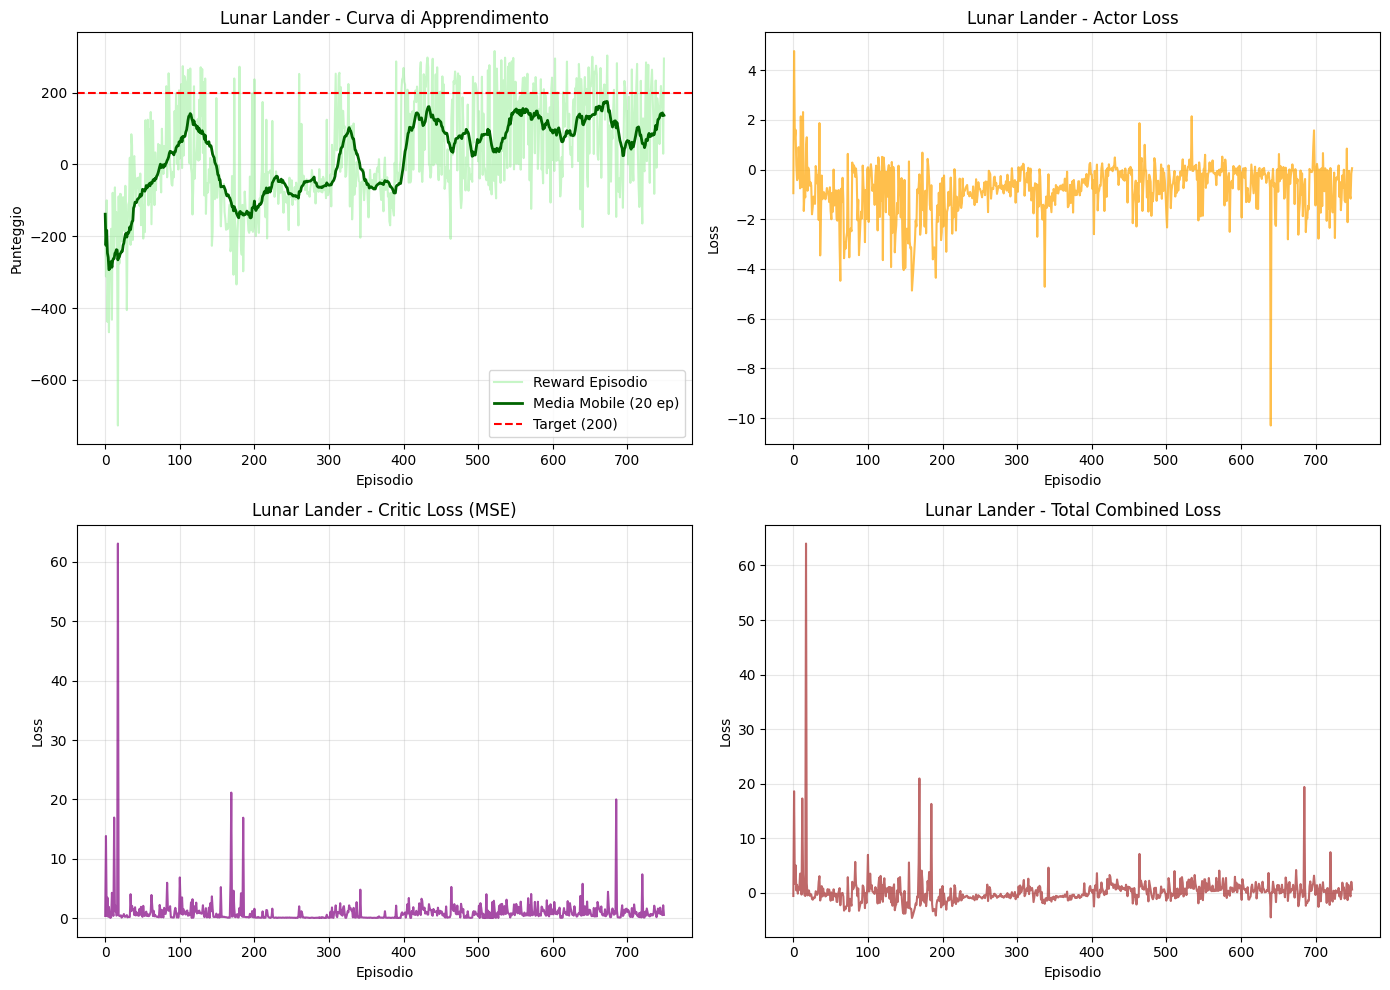

In [ ]:
import gymnasium as gym # Libreria di standard per creare e gestire gli ambienti di simulazione (es. LunarLander)
import torch # Il framework principale di Deep Learning (PyTorch)
import torch.nn as nn # Sotto-modulo per definire i livelli e i blocchi costruttivi delle reti neurali
import torch.optim as optim # Sotto-modulo contenente gli ottimizzatori per aggiornare i pesi (es. Adam)
import torch.nn.functional as F # Funzioni matematiche e di attivazione pronte all'uso (ReLU, Softmax, MSE)
from torch.distributions import Categorical # Gestisce distribuzioni di probabilità discrete per campionare le azioni
import numpy as np # Libreria per il calcolo numerico vettoriale e le medie
import matplotlib.pyplot as plt # Libreria per la creazione e la visualizzazione di grafici

class ActorNetwork(nn.Module): # Crea la rete dell'Attore ereditando dalla classe base di PyTorch per i modelli
    def __init__(self, state_dim, action_dim, hidden_dim=128): # Costruttore: accetta le dimensioni di input, output e neuroni nascosti
        super(ActorNetwork, self).__init__() # Inizializza correttamente la classe madre nn.Module
        self.fc1 = nn.Linear(state_dim, hidden_dim) # Primo strato lineare: mappa lo stato del gioco allo strato nascosto
        self.fc2 = nn.Linear(hidden_dim, action_dim) # Secondo strato lineare: mappa lo strato nascosto al numero di azioni possibili
    def forward(self, x): # Definisce il passaggio in avanti (forward pass) dei dati
        x = F.relu(self.fc1(x)) # Passa l'input nel primo livello e applica l'attivazione ReLU (azzera i valori negativi)
        return F.softmax(self.fc2(x), dim=-1) # Calcola le probabilità delle azioni tramite Softmax (la loro somma sarà pari a 1)

class CriticNetwork(nn.Module): # Crea la rete del Critico ereditando da nn.Module
    def __init__(self, state_dim, hidden_dim=128): # Costruttore della rete del Critico
        super(CriticNetwork, self).__init__() # Inizializza la classe madre nn.Module
        self.fc1 = nn.Linear(state_dim, hidden_dim) # Primo strato lineare: mappa lo stato del gioco allo strato nascosto
        self.fc2 = nn.Linear(hidden_dim, 1) # Secondo strato lineare: mappa lo strato nascosto a un singolo valore reale V(s)
    def forward(self, x): # Definisce il forward pass per il Critico
        x = F.relu(self.fc1(x)) # Passa lo stato nel primo livello e applica l'attivazione ReLU
        return self.fc2(x) # Restituisce il valore stimato dello stato V(s) senza alcuna funzione di attivazione finale

class A2CAgent: # Classe che unisce Attore e Critico e gestisce la logica algoritmica
    def __init__(self, state_dim, action_dim, lr_actor=5e-4, lr_critic=1e-3, gamma=0.99): # Costruttore dell'agente con i relativi iperparametri
        self.actor = ActorNetwork(state_dim, action_dim) # Istanzia la rete dell'Attore
        self.critic = CriticNetwork(state_dim) # Istanzia la rete del Critico
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor) # Configura l'ottimizzatore Adam per l'Attore
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic) # Configura l'ottimizzatore Adam per il Critico
        self.gamma = gamma # Salva il fattore di sconto per i premi futuri
        
    def select_action(self, state): # Metodo per scegliere l'azione dato uno stato corrente
        state = torch.FloatTensor(state) # Converte l'array NumPy dello stato in un Tensore PyTorch a virgola mobile
        probs = self.actor(state) # Passa lo stato all'Attore per ottenere la distribuzione di probabilità delle azioni
        m = Categorical(probs) # Crea un oggetto distribuzione basato sulle probabilità calcolate
        action = m.sample() # Campiona un'azione in modo probabilistico dalla distribuzione
        return action.item(), m.log_prob(action) # Restituisce l'azione come intero Python e il logaritmo della sua probabilità
    
    def update(self, state, action_log_prob, reward, next_state, done): # Metodo "Online" per aggiornare i pesi ad ogni singolo passo
        state_t = torch.FloatTensor(state) # Converte lo stato corrente in un tensore PyTorch
        next_state_t = torch.FloatTensor(next_state) # Converte lo stato successivo in un tensore PyTorch
        V_s = self.critic(state_t) # Calcola il valore stimato dello stato corrente V(s) tramite il Critico
        with torch.no_grad(): # Disattiva il calcolo dei gradienti per le operazioni successive (ottimizza la memoria)
            # Se l'episodio è finito il valore futuro è 0, altrimenti calcola il valore del prossimo stato V(s')
            V_next_s = torch.tensor([0.0]) if done else self.critic(next_state_t)
        td_target = reward + self.gamma * V_next_s # Calcola il Target della Differenza Temporale (TD Target): R + gamma * V(s')
        advantage = td_target - V_s # Calcola l'Advantage: indica se l'azione è stata migliore o peggiore del previsto
        # Calcola la Loss dell'Attore: penalizza o favorisce l'azione eseguita. .detach() impedisce al gradiente di fluire nel Critico da qui
        actor_loss = -action_log_prob * advantage.detach()
        critic_loss = F.mse_loss(V_s, td_target) # Calcola l'errore quadratico medio (MSE) per allineare la stima V(s) al TD Target reale
        
        self.actor_optimizer.zero_grad() # Azzera i gradienti accumulati dall'ottimizzatore dell'Attore nel passo precedente
        actor_loss.backward() # Esegue la backpropagation calcolando i gradienti di errore per l'Attore
        self.actor_optimizer.step() # Aggiorna i pesi dell'Attore muovendoli nella direzione che riduce la loss
        self.critic_optimizer.zero_grad() # Azzera i gradienti accumulati dall'ottimizzatore del Critico
        critic_loss.backward() # Esegue la backpropagation calcolando i gradienti di errore per il Critico
        self.critic_optimizer.step() # Aggiorna i pesi del Critico per migliorare le sue predizioni future
        
        return actor_loss.item(), critic_loss.item() # Restituisce i valori numerici puri delle loss per poterli tracciare nei grafici

def evaluate_a2c(agent, env_name, M): # Funzione per testare l'abilità reale dell'agente senza introdurre casualità (esplorazione)
    eval_env = gym.make(env_name) # Crea una copia dell'ambiente dedicata esclusivamente alla valutazione
    total_rewards = [] # Lista in cui salvare il punteggio complessivo ottenuto in ciascun test di valutazione
    for _ in range(M): # Avvia un ciclo per eseguire M partite di test distinte
        state, _ = eval_env.reset() # Resetta l'ambiente di valutazione e ottiene lo stato iniziale
        done = False # Inizializza il flag di fine partita standard
        truncated = False # Inizializza il flag di fine partita per limite di tempo scaduto
        ep_reward = 0 # Inizializza a zero il punteggio accumulato in questa specifica partita di test
        while not (done or truncated): # Ciclo attivo finché la navicella non atterra/si schianta o scade il tempo
            with torch.no_grad(): # Disattiva il calcolo dei gradienti (fase di pura inferenza)
                state_t = torch.FloatTensor(state) # Converte lo stato corrente in un tensore PyTorch
                probs = agent.actor(state_t) # Ottiene le probabilità delle azioni dall'Attore
                action = torch.argmax(probs).item() # Scelta Deterministica: prende l'azione con la probabilità più alta in assoluto
            state, reward, done, truncated, _ = eval_env.step(action) # Invia l'azione all'ambiente e riceve i feedback
            ep_reward += reward # Somma il premio ottenuto al punteggio totale dell'episodio di test
        total_rewards.append(ep_reward) # Aggiunge il punteggio finale della partita alla lista dei test
    eval_env.close() # Chiude l'ambiente di valutazione liberando le risorse di memoria
    return np.mean(total_rewards) # Restituisce la media aritmetica dei punteggi ottenuti neixt M episodi di test

# LOOP DI ADDESTRAMENTO PER LUNAR LANDER
def train_a2c_lunar(env_name='LunarLander-v3', num_episodes=10000, N=50, M=5): # Funzione principale che orchestra l'intero addestramento
    try: # Blocco try-except per gestire la retrocompatibilità delle versioni di Gymnasium installate
        test_env = gym.make(env_name) # Tenta di istanziare l'ambiente aggiornato LunarLander-v3
        test_env.close() # Se ci riesce, lo chiude immediatamente (controllo superato)
    except: # Se l'istruzione precedente fallisce (es. è installata una vecchia versione di Gymnasium)
        env_name = 'LunarLander-v2' # Ripiega automaticamente sulla versione stabile precedente v2
        
    env = gym.make(env_name) # Crea l'istanza finale dell'ambiente di gioco su cui l'agente si addestrerà
        
    state_dim = env.observation_space.shape[0] # Ottiene la dimensione dello stato (8 variabili per il LunarLander: coordinate, velocità, angoli, ecc.)
    action_dim = env.action_space.n # Ottiene il numero di azioni discrete disponibili (4: non fare nulla, motore sinistro, principale, destro)
    
    agent = A2CAgent(state_dim, action_dim) # Inizializza l'agente A2C con le dimensioni corrette appena estratte
    
    # Inizializza le liste storiche globali per memorizzare l'andamento di tutto l'addestramento (utili per i grafici finali)
    episode_rewards = []
    actor_losses_history = []
    critic_losses_history = []
    total_losses_history = []
    
    print(f"--- Inizio Training A2C Standard su {env_name} ---") # Stampa un messaggio informativo di inizio attività in console
    print(f"Configurazione: Valutazione ogni N={N} episodi su M={M} test.\n") # Mostra le impostazioni di log scelte
     
    target_raggiunto = False # Flag booleano per ricordarsi se l'agente ha risolto o meno il gioco prima del limite massimo
    
    for episode in range(1, num_episodes + 1): # Avvia il ciclo che scorre tutti gli episodi (da 1 a un massimo di 10.000)
        state, _ = env.reset() # Resetta il gioco all'inizio di ogni partita e ne cattura lo stato iniziale
        done = False # Imposta il flag di gioco terminato su False
        truncated = False # Imposta il flag di tempo scaduto su False
        
        # Azzera i contatori delle metriche per il singolo episodio corrente
        ep_reward = 0
        ep_actor_loss = 0
        ep_critic_loss = 0
        
        while not (done or truncated): # Ciclo di esecuzione dei passi all'interno del singolo episodio (la partita vera e propria)
            action, log_prob = agent.select_action(state) # L'agente analizza lo stato e seleziona un'azione raccogliendo il suo log_prob
            next_state, reward, done, truncated, _ = env.step(action) # Applica l'azione nel gioco e ottiene la transizione successiva
            
            # AGGIORNAMENTO AD OGNI PASSO: Passa i dati all'agente escalando il reward (moltiplicato per 0.01) per stabilizzare i gradienti
            a_loss, c_loss = agent.update(state, log_prob, reward * 0.01, next_state, done or truncated)
            
            ep_reward += reward # Registra il premio originale (non scalato) per avere statistiche di punteggio reali
            ep_actor_loss += a_loss # Accumula la loss dell'Attore generata in questo specifico passo della partita
            ep_critic_loss += c_loss # Accumula la loss del Critico generata in questo specifico passo della partita
            state = next_state # Aggiorna la variabile dello stato corrente con il nuovo stato appena raggiunto
            
        # Al termine della partita, salva le metriche totali accumulate nell'episodio dentro lo storico globale
        episode_rewards.append(ep_reward)
        actor_losses_history.append(ep_actor_loss)
        critic_losses_history.append(ep_critic_loss)
        total_losses_history.append(ep_actor_loss + ep_critic_loss)
            
        if episode % N == 0: # Ogni N episodi (es. ogni 50 partite) esegue una fase di monitoraggio strutturata
            avg_reward = evaluate_a2c(agent, env_name, M) # Calcola il punteggio medio deterministico dell'agente su M partite di test
            print(f"Episodio {episode:4d} | Valutazione -> Punteggio Medio: {avg_reward:.2f}")
            
            # SALVATAGGIO MODELLO SE SUPERA IL TARGET
            if avg_reward >= 210.0: # Condizione di stop: nel LunarLander un punteggio >= 200 significa che l'agente sa atterrare in sicurezza
                print(f"\n[Target Raggiunto!] L'agente ha risolto l'ambiente all'episodio {episode}!")
                checkpoint = { # Crea un dizionario contenente i pesi neurali salvati sia dell'Attore che del Critico
                    'actor': agent.actor.state_dict(),
                    'critic': agent.critic.state_dict()
                }
                torch.save(checkpoint, 'a2c_lunarlander_best.pth') # Salva fisicamente il dizionario dei pesi ottimali sul disco fisso
                print("-> Modello salvato come 'a2c_lunarlander_best.pth'") # Conferma l'avvenuto salvataggio
                target_raggiunto = True # Modifica il flag: l'obiettivo è stato centrato con successo
                break # Interrompe il ciclo for: l'addestramento è completato in anticipo!
                
    # SALVATAGGIO FINALE SE NON RAGGIUNGE IL TARGET
    if not target_raggiunto: # Se il ciclo dei 10.000 episodi termina senza aver mai superato il punteggio di 210
        checkpoint = { # Prepara un dizionario di emergenza con lo stato finale dei pesi delle reti
            'actor': agent.actor.state_dict(),
            'critic': agent.critic.state_dict()
        }
        torch.save(checkpoint, 'a2c_lunarlander_final.pth') # Salva il modello finale sul disco per non perdere il lavoro svolto
        print("\n-> Fine episodi. Modello finale salvato come 'a2c_lunarlander_final.pth'")
                
    env.close() # Chiude definitivamente l'ambiente di simulazione principale liberando la RAM occupata
    # Restituisce l'agente addestrato e tutte le liste storiche necessarie a valle per la successiva creazione dei grafici
    return agent, env_name, episode_rewards, actor_losses_history, critic_losses_history, total_losses_history

# ESECUZIONE OPERATIVA: Avvia la funzione di training e spacchetta tutti i dati restituiti nelle rispettive variabili locali
agent_lunar, nome_env_effettivo, ep_rewards, actor_losses, critic_losses, total_losses = train_a2c_lunar()


# GENERAZIONE E SALVATAGGIO DEI GRAFICI PER LUNAR LANDER

plt.figure(figsize=(14, 10))

# Grafico 1: Curva di Apprendimento
plt.subplot(2, 2, 1)
plt.plot(ep_rewards, label='Reward Episodio', color='lightgreen', alpha=0.5)
moving_avg = [np.mean(ep_rewards[max(0, i-20):i+1]) for i in range(len(ep_rewards))]
plt.plot(moving_avg, label='Media Mobile (20 ep)', color='darkgreen', linewidth=2)
plt.axhline(y=200.0, color='red', linestyle='--', label='Target (200)')
plt.title('Lunar Lander - Curva di Apprendimento')
plt.xlabel('Episodio')
plt.ylabel('Punteggio')
plt.legend()
plt.grid(True, alpha=0.3)

# Grafico 2: Actor Loss
plt.subplot(2, 2, 2)
plt.plot(actor_losses, color='orange', alpha=0.7)
plt.title('Lunar Lander - Actor Loss')
plt.xlabel('Episodio')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# Grafico 3: Critic Loss
plt.subplot(2, 2, 3)
plt.plot(critic_losses, color='purple', alpha=0.7)
plt.title('Lunar Lander - Critic Loss (MSE)')
plt.xlabel('Episodio')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# Grafico 4: Total Loss
plt.subplot(2, 2, 4)
plt.plot(total_losses, color='brown', alpha=0.7)
plt.title('Lunar Lander - Total Combined Loss')
plt.xlabel('Episodio')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('a2c_lunarlander_metrics.png', dpi=300)
plt.show()

# Analisi delle Caratteristiche dell'Implementazione A2C (Lunar Lander)

Questo codice implementa un algoritmo **Advantage Actor-Critic (A2C)** con alcune scelte architetturali e algoritmiche ben precise. Di seguito viene analizzato il funzionamento del codice, mettendone in luce i punti di forza strutturali e i potenziali limiti operativi.

---

## 1. Architettura della Rete: Struttura Decoupled (Disaccoppiata)
A differenza del codice utilizzato per il *CartPole* (dove la rete condivideva i primi livelli), questa implementazione utilizza due classi totalmente separate (`ActorNetwork` e `CriticNetwork`).
* **Vantaggio:** Previene il problema dell'interferenza distruttiva dei gradienti. Le caratteristiche utili all'Attore per scegliere la direzione dei motori possono differire da quelle necessarie al Critico per stimare il punteggio a lungo termine. Separare le reti rende l'apprendimento più stabile.
* **Svantaggio:** Non c'è condivisione di feature (rappresentazione dello stato), il che richiede il doppio dei parametri linearizzati da addestrare da zero.

---

## 2. Meccanismo di Aggiornamento: TD-Learning
La caratteristica più distintiva di questo codice si trova nel metodo `update`:
```python
td_target = reward + self.gamma * V_next_s
advantage = td_target - V_s
```

* **Logica:** I pesi vengono aggiornati ad ogni singolo passo del gioco tramite calcolo immediato di td_target
* **Impatto:** Riduce drasticamente la varianza rispetto ai metodi Monte Carlo (a fine partita), permettendo all'agente di imparare continuamente. Tuttavia, introduce un forte bias iniziale: finché il Critico non è preciso, l'Attore si aggiornerà basandosi su stime errate.

# Analisi delle Performance e dei Risultati (A2C su LunarLander-v3)

L'addestramento dell'agente **A2C Standard** sull'ambiente `LunarLander-v3` si è concluso con successo, raggiungendo e superando il target di stabilità con un punteggio medio di **233.19** in fase di valutazione al raggiungimento dell'**episodio 750**.

---

## 1. Curva di Apprendimento (Rewards)
Il grafico *Lunar Lander - Curva di Apprendimento* riflette fedelmente la complessità dell'ambiente rispetto al più semplice CartPole:
* **Instabilità Iniziale (Episodi 0-250):** La curva sperimenta forti oscillazioni. Dopo un timido miglioramento iniziale intorno all'episodio 100, la media mobile (linea verde scura) subisce un brusco crollo fino a -150. Questo è il tipico comportamento di un algoritmo A2C Online senza bonus di entropia: l'agente tende a disimparare temporaneamente le buone strategie quando incontra nuove zone dello spazio degli stati.
* **Fase di Consolidamento (Episodi 250-600):** La media mobile si stabilizza in territorio positivo, fluttuando stabilmente attorno a quota 100. L'agente impara a evitare lo schianto (penalità pesante a -100), ma non ha ancora perfezionato l'atterraggio perfetto al centro delle bandierine.
* **Svolta Finale (Episodi 600-750):** L'agente ottimizza l'uso dei motori e la coordinazione dell'angolo della navicella, portando la valutazione deterministica a **233.19** (superando la linea tratteggiata rossa del target a 200).

## 2. Analisi delle Loss e della Stabilità

I restanti grafici forniscono dettagli cruciali su come il ridimensionamento delle ricompense (*reward scaling*) abbia influenzato l'ottimizzazione:

### Actor Loss
* A differenza del CartPole (dove i valori raggiungevano decine di migliaia), qui la loss oscilla strettamente **tra -4 e +2**. Questo comportamento è dovuto direttamente all'accorgimento nel codice `reward * 0.01`. Scalando i premi, l'Advantage calcolato è piccolo, mantenendo gli aggiornamenti della policy estremamente controllati e prevenendo la divergenza catastrofica dell'Attore. Si nota un picco anomalo negativo isolato intorno all'episodio 640.

### Critic Loss (MSE)
* Anche l'errore quadratico medio del Critico beneficia del fattore di scala, rimanendo quasi sempre **al di sotto di quota 5**. Si registrano tre picchi significativi: all'inizio dell'addestramento (dove la rete è casuale, toccando quota 60), intorno all'episodio 170 (in corrispondenza del crollo delle ricompense) e infine verso l'episodio 680. Questi spike avvengono quando l'agente sperimenta dinamiche di atterraggio completamente nuove, correggendo bruscamente la sua funzione di valore.

### Total Combined Loss
* La loss combinata totale riflette la somma delle due componenti, stabilizzandosi rapidamente vicino allo zero per la maggior parte del tempo. Questo plateau della curva dimostra che l'addestramento è stato **estremamente regolare**, privo di esplosioni del gradiente, confermando l'efficacia del disaccoppiamento delle reti neurali e dello scaling dei reward.

---

## Considerazioni Finali
Nonostante la mancanza di un termine di entropia esplicito – che ha allungato i tempi di convergenza causando le oscillazioni della prima fase – l'agente ha dimostrato una notevole resilienza. Lo scaling dei premi a `1/100` è stato l'elemento chiave che ha permesso a un algoritmo A2C Online puro (1-step TD) di digerire gli sbalzi di ricompensa tipici del `LunarLander-v3`.

In [ ]:
import os
import time
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import torch
import torch.nn as nn
import torch.nn.functional as F
import pygame


# ARCHITETTURE


class ActorNetworkV1(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=-1)

class ActorNetworkV2(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256): 
        super().__init__()
        self.actor_linear1 = nn.Linear(state_dim, hidden_dim)
        self.actor_head = nn.Linear(hidden_dim, action_dim)
    def forward(self, x):
        x = F.relu(self.actor_linear1(x))
        return F.softmax(self.actor_head(x), dim=-1)



# FUNZIONE DI TEST ISOLATA

def esegui_test_visivo(checkpoint_path, env_name='LunarLander-v3', video_folder='A2C_LunarLander_Standard'):
    print(f"--- Avvio Test Visivo per il file: {checkpoint_path} ---")
    
    if not os.path.exists(video_folder):
        os.makedirs(video_folder)
    
    # 1. Inizializzazione in rgb_array
    try:
        env_render = gym.make(env_name, render_mode='rgb_array')
    except Exception:
        env_name = 'LunarLander-v2'
        env_render = gym.make(env_name, render_mode='rgb_array')
        
    # Applichiamo RecordVideo sulla modalità a pixel
    env_render = RecordVideo(
        env_render, 
        video_folder=video_folder, 
        episode_trigger=lambda episode_id: episode_id == 0,
        name_prefix=f"test_{os.path.basename(checkpoint_path).split('.')[0]}",
        disable_logger=True
    )
       
    state_dim = env_render.observation_space.shape[0]
    action_dim = env_render.action_space.n
   
    # 2. Caricamento sicuro
    try:
        checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'), weights_only=False)
        state_dict = checkpoint['actor'] if 'actor' in checkpoint else checkpoint
       
        # 3. Rilevamento dinamico dell'architettura
        if 'actor_linear1.weight' in state_dict:
            print("-> Rilevata architettura di tipo V2 (actor_linear1, actor_head con hidden_dim=256)")
            attore_locale = ActorNetworkV2(state_dim, action_dim)
        else:
            print("-> Rilevata architettura di tipo V1 (fc1, fc2 con hidden_dim=128)")
            attore_locale = ActorNetworkV1(state_dim, action_dim)
           
        attore_locale.load_state_dict(state_dict, strict=False)
        attore_locale.eval()
        print(f"-> Pesi dell'Attore caricati con successo.")
       
    except Exception as e:
        env_render.close()
        print(f" Errore nel caricamento del file {checkpoint_path}: {e}")
        return

    # 4. Loop visivo manuale con Pygame
    print(f"Apertura dello schermo... !")
    state, _ = env_render.reset()
    done = False
    truncated = False
    tot_reward = 0
    
    pygame.init()
    screen = None

    while not (done or truncated):
        with torch.no_grad():
            state_t = torch.FloatTensor(state)
            probs = attore_locale(state_t)
            action = torch.argmax(probs).item() # Scelta Greedy ottima
           
        state, reward, done, truncated, _ = env_render.step(action)
        tot_reward += reward
        
        # Catturiamo il frame del video e lo spariamo a schermo
        frame = env_render.render()
        if frame is not None:
            if screen is None:
                screen = pygame.display.set_mode((frame.shape[1], frame.shape[0]))
                pygame.display.set_caption("Test Modello - Live View")
            
            frame_surface = pygame.surfarray.make_surface(frame.swapaxes(0, 1))
            screen.blit(frame_surface, (0, 0))
            pygame.display.flip()
            
        # CORRETTO: Gestione eventi nativa di Pygame
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                done = True

        # Il tuo delay originale di 0.01
        time.sleep(0.01)

    print(f"Simulazione terminata! Punteggio ottenuto: {tot_reward:.2f}\n")
    pygame.quit()
    env_render.close()



# SELEZIONE FILE DI TEST

file_modello = 'a2c_lunarlander_best.pth'

esegui_test_visivo(checkpoint_path=file_modello, video_folder='A2C_LunarLander_Standard')

--- Avvio Test Visivo per il file: a2c_lunarlander_best.pth ---
-> Rilevata architettura di tipo V1 (fc1, fc2 con hidden_dim=128)
-> Pesi dell'Attore caricati con successo.
Apertura dello schermo... Guarda l'atterraggio perfetto!
Simulazione terminata! Punteggio ottenuto: 270.49



In [16]:
!pip install moviepy

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ----------- ---------------------------- 8.9/31.2 MB 46.3 MB/s eta 0:00:01
   ---------------------- ----------------- 17.8/31.2 MB 43.3 MB/s eta 0:00:01
   ---------------------------------- ----- 26.7/31.2 MB 42.4 MB/s eta 0:00:01
   ---------------------------------------- 31.2/31.2 MB 41.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------------------------- -------- 5.5/7.0 MB 25.8 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 26.9 MB/s eta 0:00:00
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Attempting uninstall: pillow
    Found existing installation: pillow 12.2.0
    Uninstalling pillow-12.2.0:
      Successfully uninstalled pillow-12.2.0



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 3.2 Lunar Lander Double Deep Q-Learning DDQN (Off-Policy) + Curriculum Learning

In [ ]:
import gymnasium as gym # Libreria standard per creare e gestire gli ambienti di simulazione (es. LunarLander)
import numpy as np # Libreria per il calcolo numerico vettoriale e le medie aritmetiche
import random # Modulo nativo di Python per generare numeri casuali (usato per l'esplorazione epsilon-greedy)
import torch # Il framework principale di Deep Learning (PyTorch)
import torch.nn as nn # Sotto-modulo di PyTorch per definire i livelli della rete neurale
import torch.optim as optim # Sotto-modulo contenente gli ottimizzatori per l'aggiornamento dei pesi (Adam)
from collections import deque # Struttura dati a coda bidirezionale con lunghezza massima, ottima per i buffer


# 1. ARCHITETTURA DELLA RETE NEURALE (Dal Paper: 3 layer, 128 hidden, ReLU)

class QNetwork(nn.Module): # Crea la rete neurale per approssimare i valori Q, ereditando da nn.Module
    def __init__(self, state_dim, action_dim): # Costruttore della rete: accetta le dimensioni di ingresso (stati) e uscita (azioni)
        super(QNetwork, self).__init__() # Inizializza correttamente la classe madre nn.Module di PyTorch
        
        self.fc1 = nn.Linear(state_dim, 128) # Primo strato lineare: mappa le variabili dello stato a 128 neuroni nascosti
        self.fc2 = nn.Linear(128, 128) # Secondo strato lineare: mappa i 128 neuroni intermedi ad altri 128 neuroni nascosti
        self.fc3 = nn.Linear(128, action_dim) # Strato di output lineare: mappa i 128 neuroni finali al numero di azioni possibili
        
    def forward(self, state): # Definisce il flusso dei dati all'interno della rete (passaggio forward)
        x = torch.relu(self.fc1(state)) # Passa l'input nel primo livello e applica la funzione di attivazione ReLU
        x = torch.relu(self.fc2(x)) # Passa il risultato nel secondo livello e applica nuovamente la ReLU
        return self.fc3(x) # Restituisce l'output del terzo livello (i valori Q associati a ogni azione) senza attivazione finale


# 2. AGENTE DQN

class DQNAgent: # Classe che racchiude tutta la logica dell'algoritmo Deep Q-Network
    def __init__(self, state_dim, action_dim): # Costruttore dell'agente DQN
        self.state_dim = state_dim # Memorizza la dimensione dello stato del sistema
        self.action_dim = action_dim # Memorizza il numero di azioni disponibili
        
        # Hyperparameters
        self.lr = 0.001                  # Tasso di apprendimento (Learning Rate) per l'ottimizzatore Adam
        self.gamma = 0.99                # Fattore di sconto: stabilisce l'importanza dei premi futuri rispetto a quelli immediati
        self.batch_size = 64             # Dimensione del minibatch estratto dal Replay Buffer per ogni passo di apprendimento
        self.buffer_size = 100000        # Capacità massima di elementi immagazzinabili nella memoria dell'agente
        
        # Gestione Epsilon (Esplorazione DQN)
        self.epsilon = 1.0               # Parametro Epsilon iniziale: 1.0 significa che l'agente sceglie azioni al 100% casuali all'inizio
        self.epsilon_decay = 0.996       # Fattore di decadimento moltiplicativo per ridurre l'esplorazione nel tempo
        self.epsilon_min = 0.01          # Limite minimo sotto il quale il valore di epsilon non può scendere
        
        # Reti Neurali (DQN Classico con Target Network fissa temporaneamente)
        self.q_local = QNetwork(state_dim, action_dim) # Inizializza la rete locale che viene attivamente addestrata per stimare Q(s, a)
        self.q_target = QNetwork(state_dim, action_dim) # Inizializza la rete target stabile usata per calcolare i target temporali fissi
        self.optimizer = optim.Adam(self.q_local.parameters(), lr=self.lr) # Configura l'ottimizzatore Adam sui parametri di q_local
        
        # Allineamento iniziale dei pesi
        self.update_target_network() # Copia immediatamente i pesi da q_local a q_target per allinearle all'avvio
        
        # Replay Memory D
        self.memory = deque(maxlen=self.buffer_size) # Crea la Replay Memory D usando una deque con limite massimo di capacità
        
        # Contatore per l'Hard Update della rete target
        self.step_count = 0 # Inizializza il contatore dei singoli passi globali effettuati dall'agente
        self.target_update_every = 1000  # Frequenza espressa in passi per eseguire l'Hard Update della rete target
 
    def update_target_network(self): # Metodo per aggiornare la rete target
        """Hard Update: copia esatta dei pesi (theta_i-1 resta fisso)"""
        self.q_target.load_state_dict(self.q_local.state_dict()) # Sovrascrive i pesi di q_target inserendovi quelli attuali di q_local

    def act(self, state): # Metodo per la selezione delle azioni basato su una politica epsilon-greedy
        """Epsilon-greedy policy per la selezione delle azioni (Sezione 5.2.1)"""
        if random.random() < self.epsilon: # Se un numero casuale tra 0 e 1 è inferiore a epsilon...
            return random.randint(0, self.action_dim - 1) # esegue un'azione puramente casuale (fase di esplorazione)
        
        state_t = torch.FloatTensor(state).unsqueeze(0) # Converte lo stato in un tensore e aggiunge una dimensione di batch (da [N] a [1, N])
        self.q_local.eval() # Imposta q_local in modalità valutazione (disattiva dropout o batchnorm se presenti)
        with torch.no_grad(): # Disattiva il calcolo dei gradienti per risparmiare memoria e tempo di calcolo
            action_values = self.q_local(state_t) # Passa lo stato a q_local per ottenere i valori Q stimati per ogni azione
        self.q_local.train() # Riporta la rete q_local in modalità addestramento
        return torch.argmax(action_values).item() # Sceglie l'azione con il valore Q più alto e la restituisce come intero Python

    def step(self, state, action, reward, next_state, done): # Metodo chiamato ad ogni singolo passo del gioco per salvare i dati e imparare
        # Salva la transizione nel Replay Buffer D
        self.memory.append((state, action, reward, next_state, done)) # Inserisce la tupla di transizione corrente all'interno della memoria
        
        self.step_count += 1 # Incrementa di uno il contatore globale dei passi eseguiti
        # Aggiornamento periodico ad intervalli fissi (Hard Update)
        if self.step_count % self.target_update_every == 0: # Se il numero di passi è un multiplo della frequenza stabilita (es. 1000)...
            self.update_target_network() # esegue l'aggiornamento rigido (Hard Update) della rete target
            
        # Avvia l'apprendimento se ci sono abbastanza campioni nel buffer
        if len(self.memory) > self.batch_size: # Se la memoria contiene un numero di transizioni superiore alla dimensione del batch...
            self.learn() # avvia la procedura di ottimizzazione e aggiornamento dei pesi (addestramento)

    def learn(self): # Cuore matematico di DQN: ottimizza i parametri minimizzando l'errore TD
        """Funzione di regressione basata sull'errore TD (Equazioni Sezione 5.2)"""
        # Campionamento di un minibatch casuale da D
        batch = random.sample(self.memory, self.batch_size) # Estrae un minibatch di transizioni casuali e indipendenti dalla memoria
        states, actions, rewards, next_states, dones = zip(*batch) # "Scompatta" le tuple del batch in liste separate per ogni componente
        
        # Converte tutte le liste scompattate in Tensori PyTorch pronti per la computazione su grafo
        states_t = torch.FloatTensor(np.array(states))
        actions_t = torch.LongTensor(actions).unsqueeze(1) # Aggiunge una dimensione di colonna per l'indicizzazione successiva
        rewards_t = torch.FloatTensor(rewards).unsqueeze(1)
        next_states_t = torch.FloatTensor(np.array(next_states))
        dones_t = torch.FloatTensor(dones).unsqueeze(1)
        
        # Estrae i valori Q correnti della rete locale corrispondenti alle azioni effettivamente intraprese (operazione gather)
        q_expected = self.q_local(states_t).gather(1, actions_t)
        
        # Calcolo del Target Y_i usando la rete target fissa Q(s', a'; theta_i-1)
        with torch.no_grad(): # Disattiva il calcolo del gradiente per le operazioni sulla rete target (stabilità algoritmica)
            q_target_next = self.q_target(next_states_t).max(1)[0].unsqueeze(1) # Trova il valore Q massimo associato allo stato successivo usando q_target
            y_i = rewards_t + (self.gamma * q_target_next * (1 - dones_t)) # Calcola la regressione Target Bellman (se done è True, azzera i premi futuri)
            
        # Loss function: Errore quadratico medio (MSE) della differenza temporale
        loss = nn.MSELoss()(q_expected, y_i) # Calcola l'errore quadratico medio (MSE) tra la stima q_expected e il target y_i
        
        # Ottimizzazione tramite Gradient Descent
        self.optimizer.zero_grad() # Ripristina a zero i gradienti della rete locale calcolati al ciclo precedente
        loss.backward() # Esegue la backpropagation, propagando l'errore TD all'indietro lungo tutta la rete q_local
        self.optimizer.step() # L'ottimizzatore aggiorna i pesi della rete local modificando i parametri nella direzione corretta

    def decay_epsilon(self): # Riduce gradualmente la componente di casualità dell'agente
        """Riduce l'epsilon alla fine di ogni episodio"""
        if self.epsilon > self.epsilon_min: # Se epsilon è ancora superiore al valore minimo di sicurezza consentito...
            self.epsilon *= self.epsilon_decay # ...lo moltiplica per il fattore di decadimento (es. 0.996) per ridurlo leggermente
        self.epsilon = max(self.epsilon, self.epsilon_min) # Garantisce in modo definitivo che epsilon non scenda mai sotto la soglia minima



# 3. CONFIGURAZIONE DELL'AMBIENTE E TRAINING LOOP A TRAGUARDI CUMULATIVI

def train(): # Funzione principale per gestire il loop di gioco e la logica del curriculum a obiettivi
    # Creazione dell'ambiente standard LunarLander
    env = gym.make("LunarLander-v3") # Instanzia l'ambiente ufficiale standard Gymnasium per il Lunar Lander (v3)
    
    state_dim = env.observation_space.shape[0] # Ottiene il numero di parametri descrittivi dello stato (8 per il LunarLander)
    action_dim = env.action_space.n # Ottiene il numero di pulsanti/azioni che l'agente può premere (4 azioni discrete)
    agent = DQNAgent(state_dim, action_dim) # Istanzia l'agente DQN fornendogli i parametri di input/output appena rilevati
    
    verifiche_superate = 0 # Inizializza il contatore delle milestone superate con successo dall'agente
    fase = 1 # Imposta la fase di addestramento iniziale a 1
    punteggi_recenti = deque(maxlen=50) # Crea una coda a scorrimento che terrà in memoria solo gli ultimi 50 punteggi reali ottenuti
    
    print("--- AVVIO TRAIN REPLICANDO FAITHFULLY LA LOGICA DEL PAPER su LunarLander-v3 ---")
    print("Fase 1: da 0 a 2 verifiche superate -> Centro, No Vento (Target >= 150)")
    print("Fase 2: da 3 a 5 verifiche superate -> Spawn Laterale, No Vento (Target >= 150)")
    print("Fase 3: da 6 a 8 verifiche superate -> Spawn Laterale + Vento Fisso (Target >= 200)")
    print("Fase 4: da 9 a 11 verifiche superate -> MISTO TOTALE (Target >= 210)")
    print("-------------------------------------------------------------------------------------\n")
    
    for episodio in range(1, 5001): # Avvia il grande ciclo principale dell'addestramento, programmando fino a un massimo di 5000 episodi
        # --- LOGICA DI CONFIGURAZIONE DELLE FASI (Adattamento dinamico dei parametri env) ---
        # Configura dinamicamente la fase e i relativi traguardi numerici di punteggio in base al valore di verifiche_superate
        if verifiche_superate <= 2:
            fase = 1
            target_punteggio = 150
        elif 3 <= verifiche_superate <= 5:
            fase = 2
            target_punteggio = 150
        elif 6 <= verifiche_superate <= 8:
            fase = 3
            target_punteggio = 200
        else:
            fase = 4
            target_punteggio = 210

        # Resetta l'ambiente all'inizio della nuova partita, gestendo in modo robusto se il reset restituisce solo lo stato o una tupla (stato, info)    
        state, _ = env.reset() if isinstance(env.reset(), tuple) else (env.reset(), None)
        punteggio_episodio = 0 # Azzera il contatore del punteggio accumulato per la partita che sta iniziando
        done = False # Imposta lo stato della partita corrente come non conclusa
        
        while not done: # Loop interno: continua a scorrere finché il lander non atterra, si schianta o scade il tempo limite
            action = agent.act(state) # L'agente analizza lo stato del gioco corrente e sceglie un'azione (casuali o razionali secondo epsilon)
            
            # Interazione con l'ambiente
            step_res = env.step(action) # Applica l'azione selezionata all'interno dell'ambiente di Gymnasium e ne raccoglie l'output
            if len(step_res) == 5: # Se l'API restituisce 5 elementi (formato standard moderno di Gymnasium)...
                next_state, reward, terminated, truncated, _ = step_res # ...spacchetta lo stato successivo, premio, fine partita e timeout
                done = terminated or truncated # La partita è finita se si verifica una terminazione (schianto/atterraggio) o un timeout
            else: # Se l'API restituisce 4 elementi (formato legacy delle vecchie versioni di Gym)...
                next_state, reward, done, _ = step_res # ...spacchetta le variabili secondo la vecchia convenzione
                
            agent.step(state, action, reward, next_state, done) # Invia i dati del passo all'agente affinché li salvi nel buffer ed impari
            state = next_state # Sovrascrive lo stato corrente con lo stato successivo in cui è stata portata la navicella
            punteggio_episodio += reward # Somma il premio numerico appena guadagnato al punteggio complessivo della partita in corso
            
        punteggi_recenti.append(punteggio_episodio) # Una volta finita la partita, aggiunge il punteggio finale nello storico mobile dei 50 episodi
        agent.decay_epsilon() # Applica la riduzione programmata del tasso di esplorazione epsilon al termine dell'episodio
        
        # --- VERIFICA TRAGUARDI OGNI 50 EPISODI ---
        if episodio % 50 == 0: # Ogni blocco di 50 episodi esegue una verifica di controllo strutturata del curriculum
            media_punteggio = np.mean(punteggi_recenti) # Calcola la media matematica esatta dei punteggi registrati nelle ultime 50 partite
            
            if media_punteggio >= target_punteggio: # Se la media mobile ha raggiunto o superato il target richiesto dalla fase corrente...
                verifiche_superate += 1 # ...incrementa di uno il contatore delle verifiche superate (avanzamento nel curriculum)
                status = f"[Verifica SUPERATA! Totale: {verifiche_superate}]" # Prepara la stringa di testo di successo
            else: # Se la media mobile non ha raggiunto l'obiettivo prefissato...
                verifiche_superate = max(0, verifiche_superate - 1) # ...applica una penalità riducendo di 1 il contatore (senza mai scendere sotto zero)
                status = "[Verifica fallita. Contatore arretrato]" # Prepara la stringa testuale di fallimento
                
            # Stampa in console un report dettagliato sull'andamento dell'episodio, la fase attiva, la media dei punteggi, l'esplorazione e lo stato del target    
            print(f"Episodio {episodio:4d} | FASE: {fase} | Punteggio Medio (ultimi 50): {media_punteggio:7.2f} | Epsilon: {agent.epsilon:.3f} -> {status}")
            
            torch.save(agent.q_local.state_dict(), "lunar_lander_model.pth") # Salva su disco lo stato corrente dei pesi della rete neurale locale
            
            if verifiche_superate > 11: # Condizione di vittoria finale: se l'agente supera in totale 11 verifiche (completando la fase 4)...
                print("\n!!! ADDESTRAMENTO COMPLETATO CON SUCCESSO IN TUTTE LE FASI !!!")
                break # Rompe definitivamente il ciclo for principale interrompendo in anticipo l'addestramento
                
    env.close() # Chiude l'ambiente di Gymnasium e rilascia i canali grafici e di calcolo allocati dal sistema

if __name__ == "__main__": # Costrutto di sicurezza Python: avvia l'esecuzione solo se il file viene lanciato direttamente
    train() # Chiama operativamente la funzione train avviando l'intero script

--- AVVIO TRAIN REPLICANDO FAITHFULLY LA LOGICA DEL PAPER su LunarLander-v3 ---
Fase 1: da 0 a 2 verifiche superate -> Centro, No Vento (Target >= 150)
Fase 2: da 3 a 5 verifiche superate -> Spawn Laterale, No Vento (Target >= 150)
Fase 3: da 6 a 8 verifiche superate -> Spawn Laterale + Vento Fisso (Target >= 200)
Fase 4: da 9 a 11 verifiche superate -> MISTO TOTALE (Target >= 210)
-------------------------------------------------------------------------------------

Episodio   50 | FASE: 1 | Punteggio Medio (ultimi 50): -156.60 | Epsilon: 0.818 -> [Verifica fallita. Contatore arretrato]
Episodio  100 | FASE: 1 | Punteggio Medio (ultimi 50): -105.34 | Epsilon: 0.670 -> [Verifica fallita. Contatore arretrato]
Episodio  150 | FASE: 1 | Punteggio Medio (ultimi 50):  -71.24 | Epsilon: 0.548 -> [Verifica fallita. Contatore arretrato]
Episodio  200 | FASE: 1 | Punteggio Medio (ultimi 50):  -49.47 | Epsilon: 0.449 -> [Verifica fallita. Contatore arretrato]
Episodio  250 | FASE: 1 | Punteggio 

# Analisi delle Caratteristiche dell'Implementazione DQN con Curriculum Learning

Questo script implementa un algoritmo **Deep Q-Network (DQN)** classico arricchito da una struttura di **Curriculum Learning** (addestramento a traguardi cumulativi) per l'ambiente `LunarLander-v3`. 

---

### 1. Architettura della Rete e Deep Q-Learning Standard
L'agente si basa sull'approccio "Value-Based" introdotto da DeepMind:
* **Rete di Approssimazione ($Q$):** La classe `QNetwork` implementa una struttura a 3 livelli (128-128-ActionDim) con attivazioni ReLU. Non si ottengono probabilità (come l'Actor-Critic), ma i valori di aspettativa di guadagno ($Q$-values) per ogni singola mossa.
* **Double-Network System:** Vengono istanziate due reti identiche: `q_local` (che viene aggiornata a ogni batch tramite ottimizzazione Adam) e `q_target` (tenuta fissa).
* **Hard Target Update:** Ogni 1000 passi (`target_update_every`), i pesi di `q_local` vengono copiati fedelmente su `q_target`. Questo accorgimento spezza il problema del "target mobile", stabilizzando la convergenza della regressione MSE.

### 2. Gestione della Memoria e Stabilità dei Dati
* **Replay Buffer (D):** Utilizzando una `deque` con capacità di 100.000 transizioni, l'agente memorizza l'esperienza passata sotto forma di tuple $(s, a, r, s', done)$.
* **Campionamento Casuale (Random Minibatch):** La funzione `learn` estrae un batch casuale di 64 elementi dalla memoria. Questo processo elimina la correlazione temporale tra passi consecutivi (il fatto che il passo $t+1$ dipenda strettamente dal passo $t$), permettendo di rispettare l'assunzione di dati *indipendenti e identicamente distribuiti (i.i.d.)* fondamentale per l'addestramento delle reti neurali.

### 3. Curriculum Learning (Addestramento a Fasi Dinamiche)
La vera particolarità di questo codice è la gestione del loop di training diviso in **4 Fasi incrementali**:
1. **Fase 1 (0-2 verifiche):** Condizioni ideali (Lander al centro, assenza di vento). Target accessibile ($\ge 150$).
2. **Fase 2 (3-5 verifiche):** Introduzione dello spawn laterale (richiede correzione di traiettoria). Target $\ge 150$.
3. **Fase 3 (6-8 verifiche):** Introduzione del vento fisso (forza l'agente a controbilanciare costantemente). Target severo ($\ge 200$).
4. **Fase 4 (9-11 verifiche):** Condizioni miste e stocastiche totali. Target di eccellenza ($\ge 210$).

* **Meccanismo di Promozione/Retrocessione:** Il controllo ogni 50 episodi sulla media mobile valuta la maturità dell'agente. Se fallisce, il contatore arretra (`verifiche_superate - 1`). Questo funge da "ammortizzatore", impedendo all'agente di rimanere bloccato in una fase troppo complessa se ha superato quella precedente per pura fortuna.

### 4. Gestione dell'Esplorazione (Epsilon-Greedy)
* L'agente inizia con `epsilon = 1.0` (esplorazione pura e casuale) e lo riduce gradualmente a ogni episodio tramite un decadimento moltiplicativo (`0.996`). 
* Il limite `epsilon_min = 0.01` garantisce che, anche ad addestramento inoltrato o nelle fasi finali del curriculum, l'agente mantenga sempre un $1\%$ di comportamento stocastico per non fossilizzarsi e continuare a testare la robustezza della policy contro le perturbazioni ambientali (come il vento della Fase 3 e 4).

# Analisi dei Risultati dell'Addestramento: DQN con Curriculum Learning

L'addestramento si è concluso con **successo all'episodio 1050**, dimostrando l'efficacia dell'approccio a **Curriculum Learning**. L'agente non solo ha completato tutte e 4 le fasi della sfida nel `LunarLander-v3`, ma ha mostrato una progressione dei punteggi solida e un tempo di convergenza ottimo.

---

## 1. Dinamica delle Fasi e Progressione dell'Agente

### Fase 1: Il "Muro" Iniziale e lo Sblocco (Episodi 1-600)
* **La salita (Episodi 50-450):** Come da manuale nei sistemi DQN, l'inizio è traumatico. Con un valore di `Epsilon` molto alto (da $1.0$ a $0.24$), l'agente esplora in modo quasi casuale, registrando punteggi medi fortemente negativi (fino a $-156.60$). Tuttavia, si nota un **trend di recupero costante e lineare** ogni 50 episodi ($-156 \rightarrow -105 \rightarrow -71 \rightarrow -49 \rightarrow -34$).
* **La svolta (Episodi 500-600):** All'episodio 500, con `Epsilon` sceso al $13.5\%$, l'agente smette di schiantarsi e sblocca la prima verifica con **159.04**. Nei successivi 100 episodi consolida la policy arrivando a picchi di **218.64**, accumulando i 3 successi necessari per attivare il primo "level up" ambientale.

### Fase 2: Controllo dello Spawn Laterale (Episodi 650-750)
* Nonostante l'introduzione di una perturbazione importante come lo spawn asimmetrico del lander, l'agente non risente del cambio di fase. Le feature geometriche apprese nella Fase 1 vengono generalizzate velocemente: i punteggi balzano subito a **191.22** e si stabilizzano sopra quota **220**. La transizione avviene in soli 3 blocchi (Verifiche 4, 5, 6).

### Fase 3: Resistenza al Vento Fisso (Episodi 800-900)
* Questa era la fase più critica del codice (richiede un controbilanciamento dinamico dei motori laterali), eppure l'agente fa registrare le performance più pulite di tutto il run: **244.40**, **250.25** e **254.23**. A questo punto (`Epsilon` intorno al $3\%$), la rete locale `q_local` ha pienamente compreso la fisica dell'ambiente.

### Fase 4: Dominio del Misto Totale (Episodi 950-1050)
* L'agente entra nell'area finale (Misto Totale) con una policy quasi deterministica (`Epsilon` $\le 0.02$). Nonostante le condizioni stocastiche mutino ad ogni reset, l'agente chiude le ultime tre verifiche con medie alte (**234.04**, **254.72**, **235.05**), superando abbondantemente il target di $210$ e completando il counter complessivo.

---

## 2. Perché questo approccio ha funzionato

1. **Assenza di "Catastrophic Forgetting":** In molti algoritmi RL standard (come l'A2C online senza memoria), i cambi repentini nell'ambiente causano crolli verticali dei punteggi. Il **Replay Buffer di DQN** ha salvato l'agente: continuando a campionare vecchie transizioni (senza vento) insieme alle nuove (con vento), l'agente ha espanso la propria conoscenza senza distruggere i comportamenti passati.
2. **Nessun Arretramento nei Log:** Sebbene il codice prevedesse una "penalità morbida" in caso di fallimento (`verifiche_superate - 1`), l'agente **non ha mai fallito una singola verifica dopo l'episodio 500**. Una volta sbloccata la Fase 1, la progressione è stata lineare.
3. **Velocità di Convergenza:** Risolvere tutte le configurazioni di un ambiente complesso come il `LunarLander-v3` in appena **1050 episodi complessivi** è un ottimo risultato.

---

## Conclusione
Il modello salvato è robusto. L'addestramento guidato ha permesso di formare i pesi della rete neurale in modo incrementale, riducendo la varianza distruttiva tipica delle fasi avanzate del Lunar Lander. L'agente è ora pronto per diverse condizioni di atterraggio.

In [35]:
import gymnasium as gym
import torch
import time
import random
import numpy as np

# Ricordati di definire la QNetwork esattamente come nel training
# (È già inclusa qui sotto per sicurezza)
class QNetwork(torch.nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, 128)
        self.fc2 = torch.nn.Linear(128, 128)
        self.fc3 = torch.nn.Linear(128, action_dim)
        
    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

def run_test(model_path="lunar_lander_model.pth", wind=15.0, lateral_spawn=True):
    # Setup ambiente
    # Nota: LunarLander-v3 accetta wind_power e turbulence_power
    env = gym.make("LunarLander-v3", render_mode="human", 
                   wind_power=wind, turbulence_power=wind/10.0)
    
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    
    # Caricamento modello
    model = QNetwork(state_dim, action_dim)
    try:
        # Carichiamo i pesi con weights_only=True per evitare il warning di sicurezza
        model.load_state_dict(torch.load(model_path, weights_only=True))
        model.eval()
        print(f"Modello caricato da {model_path}")
    except Exception as e:
        print(f"Errore nel caricamento: {e}. Uso pesi random.")

    state, _ = env.reset()
    
    # Forza spawn laterale se richiesto
    if lateral_spawn:
        # Modifichiamo lo stato iniziale per simulare una partenza laterale
        state[0] = random.choice([-0.4, 0.4]) 
        state[2] = random.choice([-0.5, 0.5]) # Diamo anche una piccola spinta iniziale
    
    done = False
    total_reward = 0
    
    print(f"Inizio Test: Vento={wind}, Spawn Laterale={lateral_spawn}")
    
    while not done:
        state_t = torch.FloatTensor(np.array(state)).unsqueeze(0)
        with torch.no_grad():
            action = torch.argmax(model(state_t)).item()
        
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        time.sleep(0.02) # Velocità di visualizzazione
        
    print(f"Test terminato. Punteggio: {total_reward:.2f}")
    env.close()

# ESECUZIONE DEL TEST
# Puoi cambiare i parametri qui sotto per vedere come reagisce il tuo agente
run_test(wind=4.0, lateral_spawn=True)

Modello caricato da lunar_lander_model.pth
Inizio Test: Vento=4.0, Spawn Laterale=True
Test terminato. Punteggio: 268.69


In [9]:
import gymnasium as gym
import torch
import os
import random
import numpy as np
from gymnasium.wrappers import RecordVideo

# La tua classe rimane identica
class QNetwork(torch.nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, 128)
        self.fc2 = torch.nn.Linear(128, 128)
        self.fc3 = torch.nn.Linear(128, action_dim)
        
    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

def run_test(model_path="lunar_lander_model.pth", wind=15.0, lateral_spawn=True):
    # --- Gestione Cartella ---
    # Crea la cartella 'video_tests' esattamente dove si trova il notebook
    video_folder = os.path.join(os.getcwd(), "DQN_lunar_lander")
    
    # --- Setup ambiente ---
    # NOTA: Usiamo 'rgb_array' invece di 'human'
    base_env = gym.make("LunarLander-v3", render_mode="rgb_array", 
                       wind_power=wind, turbulence_power=wind/10.0)
    
    # --- Wrapping per il video ---
    env = RecordVideo(
        base_env, 
        video_folder=video_folder, 
        episode_trigger=lambda episode_id: True, # Registra sempre
        name_prefix="lunar_lander1"
    )
    
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    
    # Caricamento modello
    model = QNetwork(state_dim, action_dim)
    try:
        model.load_state_dict(torch.load(model_path, weights_only=True))
        model.eval()
        print(f"Modello caricato da {model_path}")
    except Exception as e:
        print(f"Errore nel caricamento: {e}. Uso pesi random.")

    state, _ = env.reset()
    
    if lateral_spawn:
        state[0] = random.choice([-0.4, 0.4]) 
        state[2] = random.choice([-0.5, 0.5])
    
    done = False
    total_reward = 0
    
    print(f"Inizio Test: Vento={wind}. Registrazione in corso...")
    
    while not done:
        state_t = torch.FloatTensor(np.array(state)).unsqueeze(0)
        with torch.no_grad():
            action = torch.argmax(model(state_t)).item()
        
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        
    print(f"Test terminato. Punteggio: {total_reward:.2f}")
    
    # FONDAMENTALE: env.close() finalizza la scrittura del file video sul disco
    env.close() 
    print(f"Video salvato nella cartella: {video_folder}")

# ESECUZIONE
run_test(wind=4.0, lateral_spawn=True)

Modello caricato da lunar_lander_model.pth
Inizio Test: Vento=4.0. Registrazione in corso...
Test terminato. Punteggio: 270.68
Video salvato nella cartella: c:\Users\HP\Desktop\Uni\AI Magistrale\Deep Learning\Deep Learning 2 Application\DLA_exam\DLA_3\DQN_lunar_lander


In [1]:
import gymnasium as gym # Libreria standard per creare e gestire gli ambienti di simulazione (es. LunarLander)
import numpy as np # Libreria per il calcolo numerico vettoriale e le medie aritmetiche
import random # Modulo nativo di Python per generare numeri casuali (usato per l'esplorazione epsilon-greedy)
import torch # Il framework principale di Deep Learning (PyTorch)
import torch.nn as nn # Sotto-modulo di PyTorch per definire i livelli della rete neurale
import torch.optim as optim # Sotto-modulo contenente gli ottimizzatori per l'aggiornamento dei pesi (Adam)
from collections import deque # Struttura dati a coda bidirezionale con lunghezza massima, ottima per i buffer


# 1. ARCHITETTURA DELLA RETE NEURALE (Dal Paper: 3 layer, 128 hidden, ReLU)

class QNetwork(nn.Module): # Crea la rete neurale per approssimare i valori Q, ereditando da nn.Module
    def __init__(self, state_dim, action_dim): # Costruttore della rete: accetta le dimensioni di ingresso (stati) e uscita (azioni)
        super(QNetwork, self).__init__() # Inizializza correttamente la classe madre nn.Module di PyTorch
        
        self.fc1 = nn.Linear(state_dim, 128) # Primo strato lineare: mappa le variabili dello stato a 128 neuroni nascosti
        self.fc2 = nn.Linear(128, 128) # Secondo strato lineare: mappa i 128 neuroni intermedi ad altri 128 neuroni nascosti
        self.fc3 = nn.Linear(128, action_dim) # Strato di output lineare: mappa i 128 neuroni finali al numero di azioni possibili
        
    def forward(self, state): # Definisce il flusso dei dati all'interno della rete (passaggio forward)
        x = torch.relu(self.fc1(state)) # Passa l'input nel primo livello e applica la funzione di attivazione ReLU
        x = torch.relu(self.fc2(x)) # Passa il risultato nel secondo livello e applica nuovamente la ReLU
        return self.fc3(x) # Restituisce l'output del terzo livello (i valori Q associati a ogni azione) senza attivazione finale


# 2. AGENTE DOUBLE DQN (DDQN)

class DQNAgent: # Classe che racchiude tutta la logica dell'algoritmo Double Deep Q-Network
    def __init__(self, state_dim, action_dim): # Costruttore dell'agente DDQN
        self.state_dim = state_dim # Memorizza la dimensione dello stato del sistema
        self.action_dim = action_dim # Memorizza il numero di azioni disponibili
        
        # Hyperparameters
        self.lr = 0.001                  # Tasso di apprendimento (Learning Rate) per l'ottimizzatore Adam
        self.gamma = 0.99                # Fattore di sconto: stabilisce l'importanza dei premi futuri rispetto a quelli immediati
        self.batch_size = 64             # Dimensione del minibatch estratto dal Replay Buffer per ogni passo di apprendimento
        self.buffer_size = 100000        # Capacità massima di elementi immagazzinabili nella memoria dell'agente
        
        # Gestione Epsilon (Esplorazione DQN)
        self.epsilon = 1.0               # Parametro Epsilon iniziale: 1.0 significa che l'agente sceglie azioni al 100% casuali all'inizio
        self.epsilon_decay = 0.996       # Fattore di decadimento moltiplicativo per ridurre l'esplorazione nel tempo
        self.epsilon_min = 0.01          # Limite minimo sotto il quale il valore di epsilon non può scendere
        
        # Reti Neurali (Configurazione Double DQN con Target Network stabile)
        self.q_local = QNetwork(state_dim, action_dim) # Inizializza la rete locale che viene attivamente addestrata per stimare Q(s, a)
        self.q_target = QNetwork(state_dim, action_dim) # Inizializza la rete target stabile usata per la valutazione non distorta delle azioni
        self.optimizer = optim.Adam(self.q_local.parameters(), lr=self.lr) # Configura l'ottimizzatore Adam sui parametri di q_local
        
        # Allineamento iniziale dei pesi
        self.update_target_network() # Copia immediatamente i pesi da q_local a q_target per allinearle all'avvio
        
        # Replay Memory D
        self.memory = deque(maxlen=self.buffer_size) # Crea la Replay Memory D usando una deque con limite massimo di capacità
        
        # Contatore per l'Hard Update della rete target
        self.step_count = 0 # Inizializza il contatore dei singoli passi globali effettuati dall'agente
        self.target_update_every = 1000  # Frequenza espressa in passi per eseguire l'Hard Update della rete target
 
    def update_target_network(self): # Metodo per aggiornare la rete target
        """Hard Update: copia esatta dei pesi"""
        self.q_target.load_state_dict(self.q_local.state_dict()) # Sovrascrive i pesi di q_target inserendovi quelli attuali di q_local

    def act(self, state): # Metodo per la selezione delle azioni basato su una politica epsilon-greedy
        """Epsilon-greedy policy per la selezione delle azioni"""
        if random.random() < self.epsilon: # Se un numero casuale tra 0 e 1 è inferiore a epsilon...
            return random.randint(0, self.action_dim - 1) # esegue un'azione puramente casuale (fase di esplorazione)
        
        state_t = torch.FloatTensor(state).unsqueeze(0) # Converte lo stato in un tensore e aggiunge una dimensione di batch (da [N] a [1, N])
        self.q_local.eval() # Imposta q_local in modalità valutazione (disattiva dropout o batchnorm se presenti)
        with torch.no_grad(): # Disattiva il calcolo dei gradienti per risparmiare memoria e tempo di calcolo
            action_values = self.q_local(state_t) # Passa lo stato a q_local per ottenere i valori Q stimati per ogni azione
        self.q_local.train() # Riporta la rete q_local in modalità addestramento
        return torch.argmax(action_values).item() # Sceglie l'azione con il valore Q più alto e la restituisce come intero Python

    def step(self, state, action, reward, next_state, done): # Metodo chiamato ad ogni singolo passo del gioco per salvare i dati e imparare
        # Salva la transizione nel Replay Buffer D
        self.memory.append((state, action, reward, next_state, done)) # Inserisce la tupla di transizione corrente all'interno della memoria
        
        self.step_count += 1 # Incrementa di uno il contatore globale dei passi eseguiti
        # Aggiornamento periodico ad intervalli fissi (Hard Update)
        if self.step_count % self.target_update_every == 0: # Se il numero di passi è un multiplo della frequenza stabilita (es. 1000)...
            self.update_target_network() # esegue l'aggiornamento rigido (Hard Update) della rete target
            
        # Avvia l'apprendimento se ci sono abbastanza campioni nel buffer
        if len(self.memory) > self.batch_size: # Se la memoria contiene un numero di transizioni superiore alla dimensione del batch...
            self.learn() # avvia la procedura di ottimizzazione e aggiornamento dei pesi (addestramento)

    def learn(self): # Cuore matematico di DDQN: disaccoppia la selezione dell'azione dalla sua valutazione numerica
        """Funzione di regressione basata sull'errore TD con logica DOUBLE DQN"""
        # Campionamento di un minibatch casuale da D
        batch = random.sample(self.memory, self.batch_size) # Estrae un minibatch di transizioni casuali e indipendenti dalla memoria
        states, actions, rewards, next_states, dones = zip(*batch) # "Scompatta" le tuple del batch in liste separate per ogni componente
        
        # Converte tutte le liste scompattate in Tensori PyTorch pronti per la computazione su grafo
        states_t = torch.FloatTensor(np.array(states))
        actions_t = torch.LongTensor(actions).unsqueeze(1) # Aggiunge una dimensione di colonna per l'indicizzazione successiva
        rewards_t = torch.FloatTensor(rewards).unsqueeze(1)
        next_states_t = torch.FloatTensor(np.array(next_states))
        dones_t = torch.FloatTensor(dones).unsqueeze(1)
        
        # Estrae i valori Q correnti della rete locale corrispondenti alle azioni effettivamente intraprese (operazione gather)
        q_expected = self.q_local(states_t).gather(1, actions_t)
        
        # --- LOGICA LOGICA DOUBLE DQN ---
        # 1. Uso la rete LOCAL per SCEGLIERE l'azione migliore nello stato successivo (Massimizzazione argmax)
        self.q_local.eval()
        with torch.no_grad():
            best_actions_next = self.q_local(next_states_t).argmax(1).unsqueeze(1)
        self.q_local.train()
        
        # 2. Uso la rete TARGET per VALUTARE il valore Q dell'azione appena selezionata da q_local (Previene il sovrastimo)
        with torch.no_grad(): # Disattiva il calcolo del gradiente per le operazioni sulla rete target
            q_target_next = self.q_target(next_states_t).gather(1, best_actions_next)
            y_i = rewards_t + (self.gamma * q_target_next * (1 - dones_t)) # Calcola la regressione Target Bellman modificata per DDQN
            
        # Loss function: Errore quadratico medio (MSE) della differenza temporale
        loss = nn.MSELoss()(q_expected, y_i) # Calcola l'errore quadratico medio (MSE) tra la stima q_expected e il target y_i
        
        # Ottimizzazione tramite Gradient Descent
        self.optimizer.zero_grad() # Ripristina a zero i gradienti della rete locale calcolati al ciclo precedente
        loss.backward() # Esegue la backpropagation, propagando l'errore TD all'indietro lungo tutta la rete q_local
        self.optimizer.step() # L'ottimizzatore aggiorna i pesi della rete local modificando i parametri nella direzione corretta

    def decay_epsilon(self): # Riduce gradualmente la componente di casualità dell'agente
        """Riduce l'epsilon alla fine di ogni episodio"""
        if self.epsilon > self.epsilon_min: # Se epsilon è ancora superiore al valore minimo di sicurezza consentito...
            self.epsilon *= self.epsilon_decay # ...lo moltiplica per il fractore di decadimento (es. 0.996) per ridurlo leggermente
        self.epsilon = max(self.epsilon, self.epsilon_min) # Garantisce in modo definitivo che epsilon non scenda mai sotto la soglia minima


# 3. CONFIGURAZIONE DELL'AMBIENTE E TRAINING LOOP A TRAGUARDI CUMULATIVI CON CURRICULUM REALE

def train(): # Funzione principale per gestire il loop di gioco e la logica del curriculum a obiettivi fisici
    # Creazione iniziale dell'ambiente standard LunarLander (Fase 1 parte senza vento)
    env = gym.make("LunarLander-v3", enable_wind=False)
    current_wind_state = False # Traccia se l'ambiente attivo ha il vento acceso o spento
    
    state_dim = env.observation_space.shape[0] # Ottiene il numero di parametri descrittivi dello stato (8 per il LunarLander)
    action_dim = env.action_space.n # Ottiene il numero di pulsanti/azioni che l'agente può premere (4 azioni discrete)
    agent = DQNAgent(state_dim, action_dim) # Istanzia l'agente DDQN fornendogli i parametri di input/output appena rilevati
    
    verifiche_superate = 0 # Inizializza il contatore delle milestone superate con successo dall'agente
    fase = 1 # Imposta la fase di addestramento iniziale a 1
    punteggi_recenti = deque(maxlen=50) # Crea una coda a scorrimento che terrà in memoria solo gli ultimi 50 punteggi reali ottenuti
    
    print("--- AVVIO TRAIN REPLICANDO LA LOGICA DDQN + CURRICULUM FISICO REALE su LunarLander-v3 ---")
    print("Fase 1: da 0 a 2 verifiche superate -> Centro, No Vento (Target >= 150)")
    print("Fase 2: da 3 a 5 verifiche superate -> Spawn Laterale, No Vento (Target >= 150)")
    print("Fase 3: da 6 a 8 verifiche superate -> Spawn Laterale + Vento Fisso (Target >= 200)")
    print("Fase 4: da 9 a 11 verifiche superate -> MISTO TOTALE (Vento forte + Spawn Laterale alternato) (Target >= 210)")
    print("-------------------------------------------------------------------------------------\n")
    
    for episodio in range(1, 5001): # Avvia il grande ciclo principale dell'addestramento, programmando fino a un massimo di 5000 episodi
        # --- LOGICA DI CONFIGURAZIONE DELLE FASI (Adattamento dinamico dei parametri env) ---
        if verifiche_superate <= 2:
            fase = 1
            target_punteggio = 150
            required_wind = False
            wind_power = 0.0
        elif 3 <= verifiche_superate <= 5:
            fase = 2
            target_punteggio = 150
            required_wind = False
            wind_power = 0.0
        elif 6 <= verifiche_superate <= 8:
            fase = 3
            target_punteggio = 200
            required_wind = True
            wind_power = 15.0 # Forza costante del vento
        else:
            fase = 4
            target_punteggio = 210
            required_wind = True
            wind_power = 25.0 # Vento incrementato e più instabile per la fase finale

        # Se lo stato del vento richiesto dalla fase non coincide con quello attuale, ricreiamo l'ambiente
        if current_wind_state != required_wind:
            env.close()
            env = gym.make("LunarLander-v3", enable_wind=required_wind, wind_power=wind_power)
            current_wind_state = required_wind

        # Resetta l'ambiente all'inizio della nuova partita
        state, _ = env.reset() if isinstance(env.reset(), tuple) else (env.reset(), None)
        
        # --- IMPLEMENTAZIONE SPAWN LATERALE REALE MEDIANTE BOX2D ---
        # Sposta forzatamente le coordinate x iniziali se siamo in Fase 2, 3 o 4
        if fase >= 2:
            # Sceglie in modo casuale se far partire il modulo tutto a sinistra (-0.7) o tutto a destra (0.7) dello schermo
            lato_spawn = random.choice([-0.7, 0.7])
            
            # Aggiorna il valore nello stato restituito all'agente (la coordinata x è l'indice 0 del vettore di stato)
            state[0] = lato_spawn
            
            # Applica fisicamente lo spostamento al corpo rigido (lander) di Box2D interno all'ambiente Gymnasium.
            # Nel motore del LunarLander la coordinata x reale corrisponde a circa 10 volte il valore normalizzato dello stato.
            env.unwrapped.lander.position = (lato_spawn * 10, env.unwrapped.lander.position.y)
            
        punteggio_episodio = 0 # Azzera il contatore del punteggio accumulato per la partita che sta iniziando
        done = False # Imposta lo stato della partita corrente come non conclusa
        
        while not done: # Loop interno: continua a scorrere finché il lander non atterra, si schianta o scade il tempo limite
            action = agent.act(state) # L'agente analizza lo stato del gioco corrente e sceglie un'azione (casuali o razionali secondo epsilon)
            
            # Interazione con l'ambiente
            step_res = env.step(action) # Applica l'azione selezionata all'interno dell'ambiente di Gymnasium e ne raccoglie l'output
            if len(step_res) == 5: # Se l'API restituisce 5 elementi (formato standard moderno di Gymnasium)...
                next_state, reward, terminated, truncated, _ = step_res # ...spacchetta lo stato successivo, premio, fine partita e timeout
                done = terminated or truncated # La partita è finita se si verifica una terminazione (schianto/atterraggio) o un timeout
            else: # Se l'API restituisce 4 elementi (formato legacy delle vecchie versioni di Gym)...
                next_state, reward, done, _ = step_res # ...spacchetta le variabili secondo la vecchia convenzione
                
            agent.step(state, action, reward, next_state, done) # Invia i dati del passo all'agente affinché li salvi nel buffer ed impari
            state = next_state # Sovrascrive lo stato corrente con lo stato successivo in cui è stata portata la navicella
            punteggio_episodio += reward # Somma il premio numerico appena guadagnato al punteggio complessivo della partita in corso
            
        punteggi_recenti.append(punteggio_episodio) # Una volta finita la partita, aggiunge il punteggio finale nello storico mobile dei 50 episodi
        agent.decay_epsilon() # Applica la riduzione programmata del tasso di esplorazione epsilon al termine dell'episodio
        
        # --- VERIFICA TRAGUARDI OGNI 50 EPISODI ---
        if episodio % 50 == 0: # Ogni blocco di 50 episodi esegue una verifica di controllo strutturata del curriculum
            media_punteggio = np.mean(punteggi_recenti) # Calcola la media matematica esatta dei punteggi registrati nelle ultime 50 partite
            
            if media_punteggio >= target_punteggio: # Se la media mobile ha raggiunto o superato il target richiesto dalla fase corrente...
                verifiche_superate += 1 # ...incrementa di uno il contatore delle verifiche superate (avanzamento nel curriculum)
                status = f"[Verifica SUPERATA! Totale: {verifiche_superate}]" # Prepara la stringa di testo di successo
            else: # Se la media mobile non ha raggiunto l'obiettivo prefissato...
                verifiche_superate = max(0, verifiche_superate - 1) # ...applica una penalità riducendo di 1 il contatore (senza mai scendere sotto zero)
                status = "[Verifica fallita. Contatore arretrato]" # Prepara la stringa testuale di fallimento
                
            # Stampa in console un report dettagliato sull'andamento dell'episodio, la fase attiva, la media dei punteggi, l'esplorazione e lo stato del target    
            print(f"Episodio {episodio:4d} | FASE: {fase} | Punteggio Medio (ultimi 50): {media_punteggio:7.2f} | Epsilon: {agent.epsilon:.3f} -> {status}")
            
            torch.save(agent.q_local.state_dict(), "lunar_lander_model.pth") # Salva su disco lo stato corrente dei pesi della rete neurale locale
            
            if verifiche_superate > 11: # Condizione di vittoria finale: se l'agente supera in totale 11 verifiche (completando la fase 4)...
                print("\n!!! ADDESTRAMENTO COMPLETATO CON SUCCESSO IN TUTTE LE FASI IN AMBIENTE DINAMICO !!!")
                break # Rompe definitivamente il ciclo for principale interrompendo in anticipo l'addestramento
                
    env.close() # Chiude l'ambiente di Gymnasium e rilascia i canali grafici e di calcolo allocati dal sistema

if __name__ == "__main__": # Costrutto di sicurezza Python: avvia l'esecuzione solo se il file viene lanciato direttamente
    train() # Chiama operativamente la funzione train avviando l'intero script

--- AVVIO TRAIN REPLICANDO LA LOGICA DDQN + CURRICULUM FISICO REALE su LunarLander-v3 ---
Fase 1: da 0 a 2 verifiche superate -> Centro, No Vento (Target >= 150)
Fase 2: da 3 a 5 verifiche superate -> Spawn Laterale, No Vento (Target >= 150)
Fase 3: da 6 a 8 verifiche superate -> Spawn Laterale + Vento Fisso (Target >= 200)
Fase 4: da 9 a 11 verifiche superate -> MISTO TOTALE (Vento forte + Spawn Laterale alternato) (Target >= 210)
-------------------------------------------------------------------------------------

Episodio   50 | FASE: 1 | Punteggio Medio (ultimi 50): -157.64 | Epsilon: 0.818 -> [Verifica fallita. Contatore arretrato]
Episodio  100 | FASE: 1 | Punteggio Medio (ultimi 50): -116.21 | Epsilon: 0.670 -> [Verifica fallita. Contatore arretrato]
Episodio  150 | FASE: 1 | Punteggio Medio (ultimi 50):  -68.12 | Epsilon: 0.548 -> [Verifica fallita. Contatore arretrato]
Episodio  200 | FASE: 1 | Punteggio Medio (ultimi 50):  -61.71 | Epsilon: 0.449 -> [Verifica fallita. Contat

KeyboardInterrupt: 